## Defining CLASS and loading files!

In [106]:
import sys
sys.path.append('/mn/stornext/u3/hassanif/projects/Neutrino_Niayesh/Analysis/nu_code/')
import library_snapshot
from library_snapshot import system_tools as tools
from library_snapshot import sim_analysis as analysis
from library_snapshot import parser as parse
import numpy as np
import pandas as pd
import pickle
########################
# Parsing the settings
# #######################
parameters = parse.parse_parameter_file('./settings.ini')
number_smaples_ini = parameters['number_samples']
sim_size_ini = parameters['simulation']
boxsize = parameters['boxsize']
bulk_species_ini = parameters['bulk_species']
snap_num_ini = parameters['snapshot_number']
sim_type_ini = parameters['sim_type']
mass_limit = parameters['mass_limit']
data_load = tools.nested_dict(5, list)
save_path = parameters['save_path']
sim_path =parameters['sim_path']
ngrid_min =parameters['ngrid_min']
ngrid_max = parameters['ngrid_max']
ngrid_step = parameters['ngrid_step']
ngrid_ini = range(ngrid_min,ngrid_max,ngrid_step)



number_samples: [5, 25]
boxsize: 1200.0
mass_limit: 25000000000000.0
simulation: ['L_1200_N_512']
bulk_species: ['cdm']
snapshot_number: [2]
sim_type: ['lcdm']
save_path: ./output/
sim_path: /mn/stornext/u3/hassanif/projects/Neutrino_Niayesh/simulations/
remove_subhalos: no
ngrid_min: 1
ngrid_max: 5
ngrid_step: 1


In [114]:

########################
# Parsing the settings
# #######################
parameters = parse.parse_parameter_file('./settings.ini')
number_smaples_ini = parameters['number_samples']
sim_size_ini = parameters['simulation']
boxsize = parameters['boxsize']
bulk_species_ini = parameters['bulk_species']
snap_num_ini = parameters['snapshot_number']
sim_type_ini = parameters['sim_type']
mass_limit = parameters['mass_limit']
data_load = tools.nested_dict(5, list)
save_path = parameters['save_path']
sim_path =parameters['sim_path']
ngrid_min =parameters['ngrid_min']
ngrid_max = parameters['ngrid_max']
ngrid_step = parameters['ngrid_step']
ngrid_ini = range(ngrid_min,ngrid_max,ngrid_step)

for sim_size in sim_size_ini: 
    obj = analysis.sim(boxsize)
    for bulk_species in bulk_species_ini: 
        for sim in sim_type_ini:
            for snap_num in snap_num_ini: 
                ######################
                ## particles read
                ######################
                if bulk_species=='cdm':
                    snapshot = sim_path + sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                    #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                    ptype = [1]
                    cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                    data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                    data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                ######################
                ### Neutrinos read:
                ######################
                elif bulk_species=='nu':
                    print(" \t  Analyzing bulk species: {}".format(bulk_species))
                    print(" \t  Analyzing snapshot number: {}".format(snap_num))
                    print(" \t  Analyzing simulation: {}".format(sim))
                    print(" \t  bulk chosen to : {}".format(bulk_species))                        
                    ptype=[1];
                    snapshot =  sim_path +sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                    nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                    data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                    data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                ######################
                ## halo read
                ######################
                halo_address = sim_path +sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                #pop 1
                halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                #pop 2
                halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                #pop all
                halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                data_load[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                data_load[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]

                print(" \t  Analyzing bulk species: {}".format(bulk_species))
                print(" \t  Analyzing snapshot number: {}".format(snap_num))
                print(" \t  Analyzing simulation: {}".format(sim))
                print(" \t  bulk chosen to : {}".format(bulk_species))
                print("\033[32m \t  number of  halos: "+str(np.shape(halo_all)[0])+", number of p1: "+str(np.shape(halo_p1)[0])+", number of p2: "+str(np.shape(halo_p2)[0])+" \033[0m")
                ##########
                ##########
                for number_smaples in number_smaples_ini:  
                    print("\033[34m \033[1m \n \n  ********* Analyzing sub-box count:{}".format(number_smaples)+" ********* \033[0m")
                    for ngrid in ngrid_ini: 
                        if(number_smaples>ngrid*ngrid*ngrid):
                            number_smaples_tmp = ngrid*ngrid*ngrid;
                            print("\033[31m \t  chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
                        else:
                            number_smaples_tmp = number_smaples;
                        sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
                        ## Reseting the dictionary!
                        column_names = ['simulation','parameters','n_grid', 'sub_box_index','bulk_vel_halos_i', 'bulk_vel_cdm_i', 'vp1.v_b(cdm)', 'vp2.v_b(cdm)', 'vp1.v_b(halos)', 'vp2.v_b(halos)', 'v_h.v_b(cdm)','v_h.v_b(halos)']
                        df = pd.DataFrame(columns=column_names)
                        for i in range(number_smaples_tmp):
                            sub_box_index = sub_box_lists[i]
                            ##############################
                            ##### pcl velocities in each cell
                            ##############################
                            bulk_species = 'cdm'
                            pos_cdm = data_load[sim_size][sim][bulk_species]['pos']
                            vel_cdm = data_load[sim_size][sim][bulk_species]['vel']
                            cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### All halos velocities in each cell
                            ##############################
                            pos_halo_all = data_load[sim_size][sim]['halo']['pos']
                            vel_halo_all = data_load[sim_size][sim]['halo']['vel']
                            halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### Selecting two populations of halos and computing each 
                            ##### population velocities in each cell! 
                            ##############################
                            pos_halo_p1 =  data_load[sim_size][sim]['halo_p1']['pos'] 
                            vel_halo_p1 =  data_load[sim_size][sim]['halo_p1']['vel']
                            pos_halo_p2 =  data_load[sim_size][sim]['halo_p2']['pos']
                            vel_halo_p2 =  data_load[sim_size][sim]['halo_p2']['vel']
                            halo_p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
                            halo_p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
                            if ( (np.shape(halo_p2_vels_i)[0]>0) and (np.shape(halo_p1_vels_i)[0])>0): # Only if we have halos from both population we do compute 

                                #############################
                                ### Bulk velocity computation
                                #############################
                                bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
                                bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm

                                ##############################
                                ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
                                ##############################
                                vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

                                vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

                                vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

                                data_saved = {
                                    'simulation':sim,
                                    'parameters':parameters,
                                    'n_grid': ngrid,
                                    'sub_box_index': sub_box_index,
                                    'bulk_vel_halos_i': bulk_vel_halos_i,
                                    'bulk_vel_cdm_i': bulk_vel_cdm_i,
                                    'vp1.v_b(cdm)':vdvb_p1_bulk_cdm ,
                                    'vp2.v_b(cdm)':vdvb_p2_bulk_cdm ,
                                    'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                                    'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
                                    'v_h.v_b(cdm)':vdvb_all_bulk_cdm ,
                                    'v_h.v_b(halos)':vdvb_all_bulk_halos 
                                    }
                                df = df.append(data_saved, ignore_index=True)
                        if not os.path.exists(save_path):
                            os.makedirs(save_path)
                        with open(save_path+'/data_ngrid_'+str(ngrid)+'_sim_'+sim_size+'_'+sim+'_snap_'+str(snap_num)+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
                            pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
                        print("\t \t *** number of grid: "+str(ngrid)+" is finished!")
                print("\033[34m \033[1m  \n \t The main loop is finished \033[0m")
                print("\033[34m \033[1m ************************************************* \033[0m")


number_samples: [5, 25]
boxsize: 1200.0
mass_limit: 25000000000000.0
simulation: ['L_1200_N_512']
bulk_species: ['cdm']
snapshot_number: [2]
sim_type: ['lcdm']
save_path: ./output/
sim_path: /mn/stornext/u3/hassanif/projects/Neutrino_Niayesh/simulations/
remove_subhalos: no
ngrid_min: 1
ngrid_max: 5
ngrid_step: 1
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 2
 	  Analyzing simulation: lcdm
 	  bulk chosen to : cdm
 	  number of  halos: 185477, number of p1: 93198, number of p2: 92279 
  
 
  ********* Analyzing sub-box count:5 ********* 
 	  chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:5


KeyboardInterrupt: 

In [108]:
for sim_size in sim_size_ini: 
    obj = analysis.sim(boxsize)
    for bulk_species in bulk_species_ini: 
        for sim in sim_type_ini:
            for snap_num in snap_num_ini: 
                ######################
                ## particles read
                ######################
                if bulk_species=='cdm':
                    snapshot = sim_path + sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                    #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                    ptype = [1]
                    cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                    data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                    data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                ######################
                ### Neutrinos read:
                ######################
                elif bulk_species=='nu':
                    print(" \t  Analyzing bulk species: {}".format(bulk_species))
                    print(" \t  Analyzing snapshot number: {}".format(snap_num))
                    print(" \t  Analyzing simulation: {}".format(sim))
                    print(" \t  bulk chosen to : {}".format(bulk_species))                        
                    ptype=[1];
                    snapshot =  sim_path +sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                    nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                    data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                    data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                ######################
                ## halo read
                ######################
                halo_address = sim_path +sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                #pop 1
                halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                #pop 2
                halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                #pop all
                halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                data_load[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                data_load[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]

                print(" \t  Analyzing bulk species: {}".format(bulk_species))
                print(" \t  Analyzing snapshot number: {}".format(snap_num))
                print(" \t  Analyzing simulation: {}".format(sim))
                print(" \t  bulk chosen to : {}".format(bulk_species))
                print("\033[32m \t  number of  halos: "+str(np.shape(halo_all)[0])+", number of p1: "+str(np.shape(halo_p1)[0])+", number of p2: "+str(np.shape(halo_p2)[0])+" \033[0m")
                ##########
                ##########
                for number_smaples in number_smaples_ini:  
                    print("\033[34m \033[1m \n \n  ********* Analyzing sub-box count:{}".format(number_smaples)+" ********* \033[0m")
                    for ngrid in ngrid_ini: 
                        if(number_smaples>ngrid*ngrid*ngrid):
                            number_smaples_tmp = ngrid*ngrid*ngrid;
                            print("\033[31m \t  chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
                        else:
                            number_smaples_tmp = number_smaples;
                        sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
                        ## Reseting the dictionary!
                        column_names = ['simulation','parameters','n_grid', 'sub_box_index','bulk_vel_halos_i', 'bulk_vel_cdm_i', 'vp1.v_b(cdm)', 'vp2.v_b(cdm)', 'vp1.v_b(halos)', 'vp2.v_b(halos)', 'v_h.v_b(cdm)','v_h.v_b(halos)']
                        df = pd.DataFrame(columns=column_names)
                        for i in range(number_smaples_tmp):
                            sub_box_index = sub_box_lists[i]
                            ##############################
                            ##### pcl velocities in each cell
                            ##############################
                            bulk_species = 'cdm'
                            pos_cdm = data_load[sim_size][sim][bulk_species]['pos']
                            vel_cdm = data_load[sim_size][sim][bulk_species]['vel']
                            cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### All halos velocities in each cell
                            ##############################
                            pos_halo_all = data_load[sim_size][sim]['halo']['pos']
                            vel_halo_all = data_load[sim_size][sim]['halo']['vel']
                            halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### Selecting two populations of halos and computing each 
                            ##### population velocities in each cell! 
                            ##############################
                            pos_halo_p1 =  data_load[sim_size][sim]['halo_p1']['pos'] 
                            vel_halo_p1 =  data_load[sim_size][sim]['halo_p1']['vel']
                            pos_halo_p2 =  data_load[sim_size][sim]['halo_p2']['pos']
                            vel_halo_p2 =  data_load[sim_size][sim]['halo_p2']['vel']
                            halo_p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
                            halo_p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
                            if ( (np.shape(halo_p2_vels_i)[0]>0) and (np.shape(halo_p1_vels_i)[0])>0): # Only if we have halos from both population we do compute 

                                #############################
                                ### Bulk velocity computation
                                #############################
                                bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
                                bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm

                                ##############################
                                ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
                                ##############################
                                vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

                                vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

                                vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

                                data_saved = {
                                    'simulation':sim,
                                    'parameters':parameters,
                                    'n_grid': ngrid,
                                    'sub_box_index': sub_box_index,
                                    'bulk_vel_halos_i': bulk_vel_halos_i,
                                    'bulk_vel_cdm_i': bulk_vel_cdm_i,
                                    'vp1.v_b(cdm)':vdvb_p1_bulk_cdm ,
                                    'vp2.v_b(cdm)':vdvb_p2_bulk_cdm ,
                                    'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                                    'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
                                    'v_h.v_b(cdm)':vdvb_all_bulk_cdm ,
                                    'v_h.v_b(halos)':vdvb_all_bulk_halos 
                                    }
                                df = df.append(data_saved, ignore_index=True)
                        if not os.path.exists(save_path):
                            os.makedirs(save_path)
                        with open(save_path+'/data_ngrid_'+str(ngrid)+'_sim_'+sim_size+'_'+sim+'_snap_'+str(snap_num)+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
                            pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
                        print("\t \t *** number of grid: "+str(ngrid)+" is finished!")
                print("\033[34m \033[1m  \n \t The main loop is finished \033[0m")
                print("\033[34m \033[1m ************************************************* \033[0m")


 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 2
 	  Analyzing simulation: lcdm
 	  bulk chosen to : cdm
 	  number of  halos: 185477, number of p1: 93198, number of p2: 92279 
  
 
  ********* Analyzing sub-box count:5 ********* 
 	  chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:5
	 	 *** number of grid: 1 is finished!
	 	 *** number of grid: 2 is finished!
	 	 *** number of grid: 3 is finished!
	 	 *** number of grid: 4 is finished!
  
 
  ********* Analyzing sub-box count:25 ********* 
 	  chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:25
	 	 *** number of grid: 1 is finished!
 	  chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:25
	 	 *** number of grid: 2 is finished!


KeyboardInterrupt: 

In [109]:
file = open("./output/data_ngrid_2_sim_L_1200_N_512_lcdm_snap_2_Nsubboxes_8.pickle",'rb')
# file = open("./../runs//run_L_512_n_256/lcdm/output/data_ngrid_1_sim_L_512_N_256_lcdm_snap_3_Nsubboxes_1.pickle",'rb')

df = pickle.load(file)


In [113]:
df

,simulation,parameters,n_grid,sub_box_index,bulk_vel_halos_i,bulk_vel_cdm_i,vp1.v_b(cdm),vp2.v_b(cdm),vp1.v_b(halos),vp2.v_b(halos),v_h.v_b(cdm),v_h.v_b(halos)
0,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[1, 1, 0]","[[-0.6042282486850057, 16.27131327067345, -42....","[[-0.6703169, 17.871914, -44.96084], [324.7513...","[2194.6248055645597, 15943.894435507542, 11810]","[2198.3856509683733, 14861.315646334266, 11384]","[2057.731526019309, 14962.491700080947, 11810]","[2064.0990146735467, 13944.6414371251, 11384]","[2196.470690883048, 15422.045841235133, 23194]","[2060.8567950906136, 14471.862566894373, 23194]"
1,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[1, 1, 1]","[[27.288033034980764, -8.46669952868941, 45.21...","[[29.753696, -9.130842, 45.119595], [324.69037...","[2936.6831407252243, 17992.558105272437, 11552]","[2922.1189650937927, 17054.690280196428, 11575]","[2868.2333215700437, 17535.838268438813, 11552]","[2853.5515106828934, 16645.091162564964, 11575]","[2929.3938108106736, 17529.432743204623, 23127]","[2860.8851155329976, 17095.825689264486, 23127]"
2,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[1, 0, 1]","[[-32.411796556709156, 12.148385683620274, 51....","[[-29.669563, 9.967429, 49.7232], [332.124, 31...","[3889.18514258422, 19029.16905481031, 11413]","[3352.3066375195967, 18066.70950686363, 11414]","[4087.3404477684144, 19977.746309656064, 11413]","[3519.5966174480764, 18983.66375409888, 11414]","[3620.7341303264725, 18556.10172564578, 22827]","[3803.456096812251, 19489.09062728694, 22827]"
3,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[0, 1, 0]","[[1.0425263202944448, 13.288299238209362, -41....","[[0.98768944, 10.548239, -42.70079], [331.8496...","[1799.7812172068957, 13916.705729063295, 11799]","[2033.6925325371474, 13290.225512457217, 11567]","[1776.1335865317646, 13795.600672942737, 11799]","[2035.1977144847185, 13186.352859702038, 11567]","[1915.5756272225178, 13610.682977191891, 23366]","[1904.3795322662431, 13498.060463857833, 23366]"
4,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[1, 0, 0]","[[-9.826779653753857, -20.56140512512856, -48....","[[-10.488385, -18.592384, -49.365616], [327.99...","[2839.8475760985098, 17539.974938929237, 11690]","[2872.555187316254, 16626.233276529565, 11646]","[2802.8151829403246, 17353.67437995441, 11690]","[2848.880156366386, 16450.4770476424, 11646]","[2856.170546626529, 17090.081220822532, 23336]","[2825.804241927294, 16908.974514683596, 23336]"
5,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[0, 0, 0]","[[10.477299864906087, -9.843462762016822, -40....","[[11.367333, -10.028279, -37.812855], [327.501...","[1619.5952948245017, 13484.617052407197, 11532]","[1861.0671076457222, 12653.228203833463, 11415]","[1701.007996345404, 14134.287519086285, 11532]","[1953.4679158589452, 13257.499254507515, 11415]","[1739.715604379312, 13078.207696384134, 22947]","[1826.5943466851904, 13705.723109590368, 22947]"
6,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[0, 0, 0]","[[10.477299864906087, -9.843462762016822, -40....","[[11.367333, -10.028279, -37.812855], [327.501...","[1619.5952948245017, 13484.617052407197, 11532]","[1861.0671076457222, 12653.228203833463, 11415]","[1701.007996345404, 14134.287519086285, 11532]","[1953.4679158589452, 13257.499254507515, 11415]","[1739.715604379312, 13078.207696384134, 22947]","[1826.5943466851904, 13705.723109590368, 22947]"
7,lcdm,"{'number_samples': [5, 25], 'boxsize': 1200.0,...",2,"[1, 1, 1]","[[27.288033034980764, -8.46669952868941, 45.21...","[[29.753696, -9.130842, 45.119595], [324.69037...","[2936.6831407252243, 17992.558105272437, 11552]","[2922.1189650937927, 17054.690280196428, 11575]","[2868.2333215700437, 17535.838268438813, 11552]","[2853.5515106828934, 16645.091162564964, 11575]","[2929.3938108106736, 17529.432743204623, 23127]","[2860.8851155329976, 17095.825689264486, 23127]"


In [112]:
df['parameters'][0]

{'number_samples': [5, 25],
 'boxsize': 1200.0,
 'mass_limit': 25000000000000.0,
 'simulation': ['L_1200_N_512'],
 'bulk_species': ['cdm'],
 'snapshot_number': [2],
 'sim_type': ['lcdm'],
 'save_path': './output/',
 'sim_path': '/mn/stornext/u3/hassanif/projects/Neutrino_Niayesh/simulations/',
 'remove_subhalos': 'no',
 'ngrid_min': 1,
 'ngrid_max': 5,
 'ngrid_step': 1}

# Let's study the whole simulation box

In [47]:
######################
## particles read
######################
snapshot = './../../simulations/L_512_N_256/lcdm//output/snap00'+str(3)+'_cdm'
#[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
ptype = [1]
boxsize = 512
data_load = tools.nested_dict(5, list)
mass_limit =2.5e13

obj = analysis.sim(boxsize)
cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
data_load['pos'] = cdm_pcl[0]; 
data_load['vel'] = cdm_pcl[1];


######################
## halo read
######################
halo_address ='./../../simulations/L_512_N_256/lcdm//output/halos/out_3.list'
#pop 1
halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
data_load['halo_p1']['pos'] = halo_p1[:,:3]
data_load['halo_p1']['vel'] = halo_p1[:,3:6]
#pop 2
halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
data_load['halo_p2']['pos'] = halo_p2[:,:3]
data_load['halo_p2']['vel'] = halo_p2[:,3:6]            
# #pop all
halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
data_load['halo']['pos'] = halo_all[:,:3]
data_load['halo']['vel'] = halo_all[:,3:6]

In [53]:
ngrid = 1 # whole box!
pos_halo_all = data_load['halo']['pos']
vel_halo_all = data_load['halo']['vel']
i=0;j=0;k=0;
halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, [i,j,k])#
halos_pos_i = obj.pos_in_cell(ngrid, pos_halo_all, vel_halo_all, [i,j,k])#
bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, [i,j,k])

pos_halo_p1 = data_load['halo_p1']['pos']
vel_halo_p1 = data_load['halo_p1']['vel']
p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, [i,j,k])#
p1_pos_i = obj.pos_in_cell(ngrid, pos_halo_p1, vel_halo_p1, [i,j,k])#
# bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, [i,j,k])

pos_halo_p2 = data_load['halo_p2']['pos']
vel_halo_p2 = data_load['halo_p2']['vel']
p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, [i,j,k])#
p2_pos_i = obj.pos_in_cell(ngrid, pos_halo_p2, vel_halo_p2, [i,j,k])#

cdm_vels_i = obj.vels_in_cell(ngrid, data_load['pos'], data_load['vel'], [i,j,k])#
cdm_pos_i = obj.pos_in_cell(ngrid, data_load['pos'], data_load['vel'], [i,j,k])#
bulk_vel_cdm_i = obj.velocity_bulk(ngrid, data_load['pos'], data_load['vel'], [i,j,k])


In [54]:
bulk_vel_halos_i

[array([-1.36862598, -1.94655776,  2.00954066]),
 array([311.66495287, 305.05676559, 312.71402908])]

In [55]:
bulk_vel_cdm_i

[array([-0.15428069, -0.00332797, -0.098885  ], dtype=float32),
 array([317.401 , 305.6253, 314.0417], dtype=float32)]

In [56]:
np.dot(bulk_vel_cdm_i[0], bulk_vel_cdm_i[0])

0.03359185

In [74]:
obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])

[0.018917228195932626, 56.956187026425624, 12518]

In [ ]:
weight = np.array([np.array(x) for x in df['vp1.v_b(cdm)']])[:,2] # number of halos in each sub-box
vector_vp1_dot_vb = np.array([np.array(x) for x in df['vp1.v_b(cdm)']])[:,0]

In [73]:
df['v_h.v_b(cdm)']

0    [0.018917228195932626, 56.956187026425624, 12518]
Name: v_h.v_b(cdm), dtype: object

In [145]:
sum_vel = (obj.sum_vel_dot_vbulk(halos_vels_i,bulk_vel_cdm_i[0]))[0]/np.dot(bulk_vel_cdm_i[0], bulk_vel_cdm_i[0])
sum_vel


1.0672179321084982

In [146]:
sum_vel = (obj.sum_vel_dot_vbulk(p1_vels_i,bulk_vel_cdm_i[0]))[0]/np.dot(bulk_vel_cdm_i[0], bulk_vel_cdm_i[0])
sum_vel

1.0381203745947702

In [147]:
sum_vel = (obj.sum_vel_dot_vbulk(halos_vels_i,bulk_vel_halos_i[0]))[0]/np.dot(bulk_vel_halos_i[0], bulk_vel_halos_i[0])
sum_vel


0.9999999999999998

In [148]:
sum_vel = (obj.sum_vel_dot_vbulk(halos_vels_i,bulk_vel_halos_i[0]))[0]/np.dot(bulk_vel_halos_i[0], bulk_vel_halos_i[0])
sum_vel


0.9999999999999998

In [149]:
sum_vel = (obj.sum_vel_dot_vbulk(cdm_vels_i,bulk_vel_cdm_i[0]))[0]/np.dot(bulk_vel_cdm_i[0], bulk_vel_cdm_i[0])
sum_vel


0.9999999

In [58]:
from library_snapshot import read_data as rd

data_all = tools.nested_dict(5, list)
sims_all =['lcdm_L_512_N_256_snap_3']
for name in sims_all:
    data1 = rd.load_pickle("./output/../../runs/run_L_512_n_256/lcdm/output/data_ngrid_1_sim_L_512_N_256_lcdm_snap_3_Nsubboxes_1.pickle")
    # data_all[name]['cdm'] = rd.load_pickle("./output/../../runs/run_L_512_n_256/lcdm/")
    # rd.process_directory(file_path, "./output", "halo")

./output/../../runs/run_L_512_n_256/lcdm/output/data_ngrid_1_sim_L_512_N_256_lcdm_snap_3_Nsubboxes_1.pickle not found.


In [85]:
import os
import re
import pandas as pd
import pickle
import numpy as np
# column_names = ['simulation','sim_info', 'snapshot_num','ngrid', 'dx','number_samples', 'alpha_p1', 'alpha_p2', 'std_alpha_p1', 'std_alpha_p2', 'num_subbox_analysed', "v_bulk_kind"]
# data_alpha = pd.DataFrame(columns=column_names)
# column_names = ['simulation','sim_info', 'snapshot_num','ngrid', 'dx','number_samples', 'alpha_p1', 'alpha_p2', 'std_alpha_p1', 'std_alpha_p2', 'num_subbox_analysed', "v_bulk_kind"]
# data_alpha = pd.DataFrame(columns=column_names)
file = open("./../runs//run_L_512_n_256/lcdm/output/data_ngrid_3_sim_L_512_N_256_lcdm_snap_3_Nsubboxes_25.pickle",'rb')
# file = open("./../runs//run_L_512_n_256/lcdm/output/data_ngrid_1_sim_L_512_N_256_lcdm_snap_3_Nsubboxes_1.pickle",'rb')

df = pickle.load(file)


In [86]:
df

,simulation,n_grid,sub_box_index,bulk_vel_halos_i,bulk_vel_cdm_i,vp1.v_b(cdm),vp2.v_b(cdm),vp1.v_b(halos),vp2.v_b(halos),v_h.v_b(cdm),v_h.v_b(halos),ngrid
0,lcdm,NaN,"[0, 0, 2]","[[4.963801337153768, 13.878662846227323, 131.8...","[[10.811784, -12.88612, 136.32117], [307.61758...","[16565.76909594413, 45118.08662921366, 598]","[19542.018394306604, 38484.156081597255, 449]","[16504.76864223087, 43780.4173628485, 598]","[19032.586111393888, 38105.22942631329, 449]","[17842.116693809225, 42426.04658307019, 1047]","[17588.8087985386, 41460.81348586331, 1047]",3.0
1,lcdm,NaN,"[1, 0, 0]","[[46.839903194578895, -93.36855759922555, -99....","[[46.337082, -103.72948, -104.77167], [324.304...","[25369.83444590033, 63840.52552269237, 561]","[18530.05760009765, 47252.49489301682, 472]","[23733.333378650525, 59543.52382013561, 561]","[17191.5527088901, 44114.95425617307, 472]","[22244.59275062554, 56966.655389119034, 1033]","[20744.25256923434, 53153.50325950612, 1033]",3.0
2,lcdm,NaN,"[2, 0, 0]","[[-35.764022099447516, -68.50205524861879, -65...","[[-52.214424, -63.191883, -59.156498], [316.69...","[9154.328388996346, 30166.76278120799, 516]","[11267.990653419396, 26990.355158777875, 389]","[9081.89414933359, 30765.8817539067, 516]","[11785.498477836358, 27646.643368625657, 389]","[10062.8528319362, 28863.30221139074, 905]","[10243.99589937511, 29495.998852899214, 905]",3.0
3,lcdm,NaN,"[1, 0, 0]","[[46.839903194578895, -93.36855759922555, -99....","[[46.337082, -103.72948, -104.77167], [324.304...","[25369.83444590033, 63840.52552269237, 561]","[18530.05760009765, 47252.49489301682, 472]","[23733.333378650525, 59543.52382013561, 561]","[17191.5527088901, 44114.95425617307, 472]","[22244.59275062554, 56966.655389119034, 1033]","[20744.25256923434, 53153.50325950612, 1033]",3.0
4,lcdm,NaN,"[2, 1, 2]","[[-26.51410638297872, 85.07774468085107, 144.9...","[[-20.27865, 110.50236, 117.368416], [303.7349...","[29783.737339819956, 52203.34573790464, 253]","[23658.17352923811, 44702.11688532173, 217]","[32117.213147581362, 54426.72640186047, 253]","[25282.687153431707, 47497.41735993561, 217]","[26955.55149535983, 48978.5563915467, 470]","[28961.697954537798, 51456.72142836452, 470]",3.0
5,lcdm,NaN,"[0, 0, 1]","[[91.98798185941043, -24.230430839002267, -46....","[[88.89953, -18.934706, -51.955544], [290.4936...","[9762.942992695307, 30780.382737273598, 472]","[12489.221272258852, 28510.152060677472, 410]","[9923.803468603952, 31181.367582341347, 472]","[12608.247936786682, 28831.446258210828, 410]","[11030.260560292872, 29777.680965512573, 882]","[11171.67447989071, 30141.571324902263, 882]",3.0
6,lcdm,NaN,"[1, 1, 2]","[[-80.87246376811594, -26.419213250517597, 80....","[[-37.118454, -3.8613355, 92.75357], [288.6038...","[13335.898722889066, 30571.479761899835, 255]","[7567.644151801842, 29403.774255095283, 228]","[16441.826979076846, 35276.153001689265, 255]","[10829.415265268242, 35002.7403409288, 228]","[10612.99594399075, 30163.69192815678, 483]","[13792.489772558498, 35258.85213153055, 483]",3.0
7,lcdm,NaN,"[0, 1, 2]","[[130.4197176470588, -42.76522352941177, 104.6...","[[62.497402, 45.00736, 80.62419], [301.9323, 2...","[13794.453507868502, 33988.636581520404, 235]","[15743.965088580282, 29618.652905775994, 190]","[29142.743074507132, 52002.87050410545, 235]","[30604.803279981417, 47642.80334721145, 190]","[14665.999861598475, 32123.21876006348, 425]","[29796.36998989564, 50105.85754068401, 425]",3.0
8,lcdm,NaN,"[0, 0, 1]","[[91.98798185941043, -24.230430839002267, -46....","[[88.89953, -18.934706, -51.955544], [290.4936...","[9762.942992695307, 30780.382737273598, 472]","[12489.221272258852, 28510.152060677472, 410]","[9923.803468603952, 31181.367582341347, 472]","[12608.247936786682, 28831.446258210828, 410]","[11030.260560292872, 29777.680965512573, 882]","[11171.67447989071, 30141.571324902263, 882]",3.0
9,lcdm,NaN,"[0, 0, 0]","[[-7.782425629290616, -90.34629290617849, -81....","[[3.1661377, -85.719315, -83.47708], [293.7765...","[14015.5

In [90]:
df['vp2.v_b(cdm)']

0     [19542.018394306604, 38484.156081597255, 449]
1       [18530.05760009765, 47252.49489301682, 472]
2     [11267.990653419396, 26990.355158777875, 389]
3       [18530.05760009765, 47252.49489301682, 472]
4       [23658.17352923811, 44702.11688532173, 217]
5     [12489.221272258852, 28510.152060677472, 410]
6      [7567.644151801842, 29403.774255095283, 228]
7     [15743.965088580282, 29618.652905775994, 190]
8     [12489.221272258852, 28510.152060677472, 410]
9      [15229.52531395789, 33280.080500565084, 395]
10     [13660.295679613137, 35209.80562683245, 166]
11     [15229.52531395789, 33280.080500565084, 395]
12     [15229.52531395789, 33280.080500565084, 395]
13      [16079.829972360256, 37248.1957520268, 211]
14      [18530.05760009765, 47252.49489301682, 472]
15     [13660.295679613137, 35209.80562683245, 166]
16    [15743.965088580282, 29618.652905775994, 190]
17     [10953.365638351124, 32296.10898351366, 241]
18      [18530.05760009765, 47252.49489301682, 472]
Name: vp2.v_

In [91]:
df['v_h.v_b(cdm)']

0     [17842.116693809225, 42426.04658307019, 1047]
1     [22244.59275062554, 56966.655389119034, 1033]
2        [10062.8528319362, 28863.30221139074, 905]
3     [22244.59275062554, 56966.655389119034, 1033]
4        [26955.55149535983, 48978.5563915467, 470]
5     [11030.260560292872, 29777.680965512573, 882]
6       [10612.99594399075, 30163.69192815678, 483]
7      [14665.999861598475, 32123.21876006348, 425]
8     [11030.260560292872, 29777.680965512573, 882]
9       [14564.17589490668, 35246.06967982357, 874]
10     [11414.660040603809, 34449.83867769882, 398]
11      [14564.17589490668, 35246.06967982357, 874]
12      [14564.17589490668, 35246.06967982357, 874]
13     [11885.272402786728, 42314.08924421165, 449]
14    [22244.59275062554, 56966.655389119034, 1033]
15     [11414.660040603809, 34449.83867769882, 398]
16     [14665.999861598475, 32123.21876006348, 425]
17     [13938.503090406253, 33849.64494508238, 501]
18    [22244.59275062554, 56966.655389119034, 1033]
Name: v_h.v_

In [94]:
np.array([np.array(x) for x in df['v_h.v_b(cdm)']])[:,0]

array([17842.11669381, 22244.59275063, 10062.85283194, 22244.59275063,
       26955.55149536, 11030.26056029, 10612.99594399, 14665.9998616 ,
       11030.26056029, 14564.17589491, 11414.6600406 , 14564.17589491,
       14564.17589491, 11885.27240279, 22244.59275063, 11414.6600406 ,
       14665.9998616 , 13938.50309041, 22244.59275063])

In [88]:
weight = np.array([np.array(x) for x in df['vp2.v_b(cdm)']])[:,2] # number of halos in each sub-box

In [99]:
vector_vp1_dot_vb = np.array([1, 0.1, 100])
weight= [1,1,10]
np.average(vector_vp1_dot_vb, weights=weight, axis=0)

83.425

In [82]:
weight = np.array([np.array(x) for x in df['v_h.v_b(cdm)']])[:,2] # number of halos in each sub-box
vector_vp1_dot_vb = np.array([np.array(x) for x in df['v_h.v_b(cdm)']])[:,0]
avg_vp1_dot_vb = np.average(vector_vp1_dot_vb, weights=weight, axis=0)
# std_vp1_dot_vb=  np.average((vector_vp1_dot_vb - np.average(vector_vp1_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

In [84]:
avg_vp1_dot_vb
# std_vp1_dot_vb

0.018917228195932626

In [87]:
weight

array([12518.])

In [13]:
vb = np.array([np.array(x) for x in df['bulk_vel_cdm_i']])
vb = vb[:,0,:]# The zeroth component picks the velocities the first component is the error!
vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself
avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for 

In [14]:
avg_vb_dot_vb

0.03359185

In [15]:
vb = np.array([np.array(x) for x in df['bulk_vel_cdm_i']])# The zeroth component picks the velocities the first component is the error!
# vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself
# avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for vb_dot_vb are more or less close to 1
# std_vb_dot_vb = np.sqrt(np.average((vb_dot_vb - np.average(vb_dot_vb))**2))

In [22]:
df["v_h.v_b(cdm)"][0][0]/avg_vb_dot_vb

0.5631493144724964

In [279]:
ll = vb[:2,0,:]
ll = np.array([[ 1,  1 ,  0 ],
       [ 0, 4, 1 ]])

In [280]:
vb_dot_vb = np.einsum('ij,ij->i', ll, ll)
vb_dot_vb

array([ 2, 17])

In [ ]:
vb_dot_vb = np.einsum('ij,ij->i', ll, ll)

In [272]:
vb_dot_vb

array([18866.408, 23884.031], dtype=float32)

In [260]:
vb = np.array([np.array(x) for x in df['bulk_vel_cdm_i']])[0]
vb

array([[ 10.811784, -12.88612 , 136.32117 ],
       [307.61758 , 327.18295 , 314.81256 ]], dtype=float32)

In [178]:
df["bulk_vel_halos_i"][0]

[array([-1.36862598, -1.94655776,  2.00954066]),
 array([311.66495287, 305.05676559, 312.71402908])]

In [179]:
df["v_h.v_b(halos)"][0]/np.dot(df["bulk_vel_halos_i"][0][0], df["bulk_vel_halos_i"][0][0])

array([1.00000000e+00, 9.65794544e+01, 1.29045189e+03])

In [189]:

vb = np.array([np.array(x) for x in df['bulk_vel_halos_i']])[0]
vb

array([[ -1.36862598,  -1.94655776,   2.00954066],
       [311.66495287, 305.05676559, 312.71402908]])

In [190]:
np.dot(df["bulk_vel_halos_i"][0][0], df["bulk_vel_halos_i"][0][0])

9.700477839960302

In [195]:
vb[0]

array([-1.36862598, -1.94655776,  2.00954066])

In [194]:
vb_dot_vb = np.einsum('ij,ij->i', vb[0], vb[0]) # dot product of v_bulk vectors with itself
avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for 

ValueError: einstein sum subscripts string contains too many subscripts for operand 0

In [192]:
vb_dot_vb

array([9.70047784e+00, 2.87984737e+05])

In [184]:
avg_vb_dot_vb

146386.22

In [174]:
df["bulk_vel_cdm_i"][0]

[array([-0.15428069, -0.00332797, -0.098885  ], dtype=float32),
 array([317.401 , 305.6253, 314.0417], dtype=float32)]

In [ ]:
-0.15428069, -0.00332797, -0.098885

-1.36862598, -1.94655776,  2.00954066

In [150]:
df = pickle.load("./output/../../runs/run_L_512_n_256/lcdm/output/data_ngrid_1_sim_L_512_N_256_lcdm_snap_3_Nsubboxes_1.pickle")
if (v_bulk_kind== "cdm"):
    if not df['bulk_vel_cdm_i'].empty:
        vb = np.array([np.array(x) for x in df['bulk_vel_cdm_i']])[0]# The zeroth component picks the velocities the first component is the error!
        vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself
        print(vb_dot_vb);
        avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for vb_dot_vb are more or less close to 1
        std_vb_dot_vb = np.sqrt(np.average((vb_dot_vb - np.average(vb_dot_vb))**2))
        # print()
        #### population 1
        weight = np.array([np.array(x) for x in df['vp1.v_b(cdm)']])[:,2] # number of halos in each sub-box
        vector_vp1_dot_vb = np.array([np.array(x) for x in df['vp1.v_b(cdm)']])[:,0]
        avg_vp1_dot_vb = np.average(vector_vp1_dot_vb, weights=weight, axis=0)
        std_vp1_dot_vb=  np.average((vector_vp1_dot_vb - np.average(vector_vp1_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

        #### population 2
        weight = np.array([np.array(x) for x in df['vp2.v_b(cdm)']])[:,2] # number of halos in each sub-box
        vector_vp2_dot_vb = np.array([np.array(x) for x in df['vp2.v_b(cdm)']])[:,0]
        avg_vp2_dot_vb = np.average(vector_vp2_dot_vb, weights=weight, axis=0)
        std_vp2_dot_vb=  np.average((vector_vp2_dot_vb - np.average(vector_vp2_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

        # computing alpha_p1, alpha_p2
        # std_alpha_p1 = (mu/nu)^2 * (std_mu^2/mu^2 + std_nu^2/nu^2) he ratio of two averages, alpha = mu/nu, can be thought of as the result of dividing two normal distributions. The variance of the ratio of two random variables is given by:
        # Var(alpha) = (mu/nu)^2 * (Var(mu)/mu^2 + Var(nu)/nu^2 - 2 * Cov(mu,nu)/(mu*nu))
        alpha_p1 = avg_vp1_dot_vb/avg_vb_dot_vb
        std_alpha_p1 = (avg_vp1_dot_vb/avg_vb_dot_vb)**2 * (std_vp1_dot_vb**2/avg_vp1_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
        # std_alpha_p1 = np.sqrt(var_alpha_p1); 

        # pop2:
        alpha_p2 = avg_vp2_dot_vb/avg_vb_dot_vb
        var_alpha_p2 = (avg_vp2_dot_vb/avg_vb_dot_vb)**2 * (std_vp2_dot_vb**2/avg_vp2_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
        std_alpha_p2 = np.sqrt(var_alpha_p2); 
        ### saving data:
        dx = boxsize/ngrid;
        sim = np.array([np.array(x) for x in df['simulation']])[0];
        sim_info = "L_"+str(boxsize)+"_N_"+str(N_grid_sim);
        data_saved = {
                'simulation':sim,
                'sim_info':sim_info,
                'snapshot_num':snap_num,
                'ngrid':ngrid,
                'dx':dx,
                'number_samples':number_samples,
                'alpha_p1':alpha_p1,
                'alpha_p2':alpha_p2,
                'std_alpha_p1':std_alpha_p1,
                'std_alpha_p2':std_alpha_p2,
                'num_subbox_analysed':np.shape(vb)[0],
                'v_bulk_kind':v_bulk_kind
                }
        data_alpha = data_alpha.append(data_saved, ignore_index=True)


elif (v_bulk_kind== "halo"):
    if not df['bulk_vel_halos_i'].empty:
        vb = np.array([np.array(x) for x in df['bulk_vel_halos_i']])[0]# The zeroth component picks the velocities the first component is the error!
        vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself
        avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for vb_dot_vb are more or less close to 1
        std_vb_dot_vb = np.sqrt(np.average((vb_dot_vb - np.average(vb_dot_vb))**2))
        # print()
        #### population 1
        weight = np.array([np.array(x) for x in df['vp1.v_b(halos)']])[:,2] # number of halos in each sub-box
        vector_vp1_dot_vb = np.array([np.array(x) for x in df['vp1.v_b(halos)']])[:,0]
        avg_vp1_dot_vb = np.average(vector_vp1_dot_vb, weights=weight, axis=0)
        std_vp1_dot_vb=  np.average((vector_vp1_dot_vb - np.average(vector_vp1_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

        #### population 2
        weight = np.array([np.array(x) for x in df['vp2.v_b(halos)']])[:,2] # number of halos in each sub-box
        vector_vp2_dot_vb = np.array([np.array(x) for x in df['vp2.v_b(halos)']])[:,0]
        avg_vp2_dot_vb = np.average(vector_vp2_dot_vb, weights=weight, axis=0)
        std_vp2_dot_vb=  np.average((vector_vp2_dot_vb - np.average(vector_vp2_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

        # computing alpha_p1, alpha_p2
        # std_alpha_p1 = (mu/nu)^2 * (std_mu^2/mu^2 + std_nu^2/nu^2) he ratio of two averages, alpha = mu/nu, can be thought of as the result of dividing two normal distributions. The variance of the ratio of two random variables is given by:
        # Var(alpha) = (mu/nu)^2 * (Var(mu)/mu^2 + Var(nu)/nu^2 - 2 * Cov(mu,nu)/(mu*nu))
        alpha_p1 = avg_vp1_dot_vb/avg_vb_dot_vb
        std_alpha_p1 = (avg_vp1_dot_vb/avg_vb_dot_vb)**2 * (std_vp1_dot_vb**2/avg_vp1_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
        # std_alpha_p1 = np.sqrt(var_alpha_p1); 

        # pop2:
        alpha_p2 = avg_vp2_dot_vb/avg_vb_dot_vb
        var_alpha_p2 = (avg_vp2_dot_vb/avg_vb_dot_vb)**2 * (std_vp2_dot_vb**2/avg_vp2_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
        std_alpha_p2 = np.sqrt(var_alpha_p2); 
        ### saving data:
        dx = boxsize/ngrid;
        sim = np.array([np.array(x) for x in df['simulation']])[0];
        sim_info = "L_"+str(boxsize)+"_N_"+str(N_grid_sim);
        data_saved = {
                'simulation':sim,
                'sim_info':sim_info,
                'snapshot_num':snap_num,
                'ngrid':ngrid,
                'dx':dx,
                'number_samples':number_samples,
                'alpha_p1':alpha_p1,
                'alpha_p2':alpha_p2,
                'std_alpha_p1':std_alpha_p1,
                'std_alpha_p2':std_alpha_p2,
                'num_subbox_analysed':np.shape(vb)[0],
                'v_bulk_kind':v_bulk_kind
                }
        data_alpha = data_alpha.append(data_saved, ignore_index=True)
if not os.path.exists(output_dir):
os.makedirs(output_dir)
with open(output_dir+'/simulation_'+str(sim)+'_'+str(sim_info)+'_snap_'+str(snap_num)+"_vbulk_"+v_bulk_kind+'_statistics.pickle', 'wb') as handle:
pickle.dump(data_alpha, handle, protocol=pickle.HIGHEST_PROTOCOL)


IndentationError: expected an indented block (<ipython-input-150-992f132d1b2d>, line 104)

In [86]:
data1["bulk_vel_cdm_i"][0]

[array([-0.15428069, -0.00332797, -0.098885  ], dtype=float32),
 array([317.401 , 305.6253, 314.0417], dtype=float32)]

In [60]:
vb = np.array([0,0,1],[0,0,1])
vb = np.array([np.array(x) for x in vb])
vb

TypeError: Field elements must be 2- or 3-tuples, got '0'

In [59]:
vb = np.array([0,0,1],[0,0,1])
vb = np.array([np.array(x) for x in vb])
vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself

TypeError: Field elements must be 2- or 3-tuples, got '0'

In [34]:
vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself
avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for 

In [50]:
def alpha_CF(vel, velocity_bulk):
    """
     Given two 3D arrays vel and velocity_bulk, this function computes the correlation coefficent of each vector in vel with the velocity_bulk vector. 
Returns the average, standard deviation, and number of vectors in vel that have been used for calculation.

Parameters:
    vel (3D array): an array of 3D vectors representing the velocities of halos/particles
    velocity_bulk (3D array): a 3D vector representing the bulk velocity of a given sub-box

Returns:
    A list of correlation coefficents, standard deviation, number of vectors in vel]
    """
    tmp = 0;
    for i in range(np.shape(vel)[0]):
        tmp +=np.dot(vel[i], velocity_bulk)/(np.linalg.norm(vel[i]))/(np.linalg.norm(velocity_bulk, axis=1))
    avg = np.mean(tmp)
    std = np.std(tmp)
    return [avg, std, np.shape(vel)[0]] # returns sum of all dot product and number of halos in that cell


In [ ]:
for i in range(np.shape(vel)[0]):
        tmp +=np.dot(vel[i], velocity_bulk)/(np.linalg.norm(vel[i], axis=1))/(np.linalg.norm(velocity_bulk, axis=1))
    avg = np.mean(tmp)
    std = np.std(tmp)
    return [avg, std, np.shape(vel)[0]] # returns sum of all dot product and number of halos in that cell


In [64]:
a = np.array([[1,2,3],[0,0,1]]);
b = np.array([0,1,1])

In [65]:
a[0]

array([1, 2, 3])

In [66]:
np.dot(a[0], b)

5

In [67]:
# (np.linalg.norm(a[1]))
(np.linalg.norm(b))

1.4142135623730951

In [56]:
alpha_CF(a, b)

AxisError: axis 1 is out of bounds for array of dimension 1

In [25]:
obj.alpha_CF(a, b)

AttributeError: 'sim' object has no attribute 'alpha_CF'

In [7]:
import library_snapshot
from library_snapshot import system_tools as tools
from library_snapshot import sim_analysis as analysis
from library_snapshot import parser as parse
import numpy as np

########################
# Parsing the settings
########################
parameters = parse.parse_parameter_file('./settings.ini')
number_smaples_ini = parameters['number_samples']
sim_size_ini = parameters['simulation']
boxsize = parameters['boxsize']
bulk_species_ini = parameters['bulk_species']
snap_num_ini = parameters['snapshot_number']
sim_type_ini = parameters['sim_type']
data_load = tools.nested_dict(5, list)

######################
## Loop over sub-boxes
######################
for number_smaples in number_smaples_ini:  
    print("\033[34m \033[1m \n \n  ********* Analyzing sub-box count: {}".format(number_smaples)+" ********* \033[0m")

    for sim_size in sim_size_ini: 
        obj = analysis.sim(boxsize)
        for bulk_species in bulk_species_ini: 
            for snap_num in snap_num_ini: 
                for sim in sim_type_ini:
                    ######################
                    ## particles read
                    ######################
                    if bulk_species=='cdm':
                        print(" \t  Analyzing bulk species: {}".format(bulk_species))
                        print(" \t  Analyzing snapshot number: {}".format(snap_num))
                        print(" \t  Analyzing simulation: {}".format(sim))
                        print(" \t  bulk chosen to : {}".format(bulk_species))
                        snapshot = './../simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                        #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                        ptype = [1]
                        cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                    ######################
                    ### Neutrinos read:
                    ######################
                    elif bulk_species=='nu':
                        print(" \t  Analyzing bulk species: {}".format(bulk_species))
                        print(" \t  Analyzing snapshot number: {}".format(snap_num))
                        print(" \t  Analyzing simulation: {}".format(sim))
                        print(" \t  bulk chosen to : {}".format(bulk_species))                        
                        ptype=[1];
                        snapshot = './../simulations//'+sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                        nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                        
                        

number_samples: [5, 25, 50, 100, 250, 500, 1000, 10000]
boxsize: 512.0
mass_limit: 15000000000000.0
simulation: ['L_512_N_256']
bulk_species: ['cdm']
snapshot_number: [2]
sim_type: ['Mn_0d6_nu_pcls', 'lcdm']
  
 
  ********* Analyzing sub-box count: 5 ********* 
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 2
 	  Analyzing simulation: Mn_0d6_nu_pcls
 	  bulk chosen to : cdm
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 2
 	  Analyzing simulation: lcdm
 	  bulk chosen to : cdm
  
 
  ********* Analyzing sub-box count: 25 ********* 
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 2
 	  Analyzing simulation: Mn_0d6_nu_pcls
 	  bulk chosen to : cdm
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 2
 	  Analyzing simulation: lcdm
 	  bulk chosen to : cdm
  
 
  ********* Analyzing sub-box count: 50 ********* 
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 2
 	  Analyzing simulation: Mn_0d6_nu_pcls
 	  bulk chosen

In [2]:
snapshot = './../simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                        #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
# ptype = [1]
# cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];

In [3]:
snapshot

'./../simulations///L_512_N_256/Mn_0d6_nu_pcls/output/snap002_cdm'

In [26]:
import library_snapshot
from library_snapshot import system_tools as tools
from library_snapshot import sim_analysis as analysis
from library_snapshot import parser as parse
import numpy as np

########################
# Parsing the settings
########################
parameters = parse.parse_parameter_file('./settings.ini')
number_smaples_ini = parameters['number_samples']
sim_size_ini = parameters['simulation']
boxsize = parameters['boxsize']
bulk_species_ini = parameters['bulk_species']
snap_num_ini = np.int(parameters['snapshot_number']
sim_type_ini = parameters['sim_type']

######################
## Loop over sub-boxes
######################
for number_smaples in number_smaples_ini:  
    print("\033[34m \033[1m \n \n  ********* Analyzing sub-box count: {}".format(number_smaples)+" ********* \033[0m")

    for sim_size in sim_size_ini: 
        obj = analysis.sim(boxsize)
        for bulk_species in bulk_species_ini: 
            print(" \t  Analyzing bulk species: {}".format(bulk_species))
            for snap_num in snap_num_ini: 
                print(" \t  Analyzing snapshot number: {}".format(snap_num))
                for sim_type in sim_type_ini:
                    print(" \t  Analyzing simulation: {}".format(sim_type))
                    
                    

number_samples: [5, 25, 50, 100, 250, 500, 1000, 10000]
boxsize: 512.0
mass_limit: 15000000000000.0
simulation: ['L_512_N_256']
bulk_species: ['cdm']
snapshot_number: [3.0]
sim_type: ['Mn_0d6_nu_pcls', 'lcdm']
  
 
  ********* Analyzing sub-box count: 5 ********* 
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 3.0
 	  Analyzing simulation: Mn_0d6_nu_pcls
 	  Analyzing simulation: lcdm
  
 
  ********* Analyzing sub-box count: 25 ********* 
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 3.0
 	  Analyzing simulation: Mn_0d6_nu_pcls
 	  Analyzing simulation: lcdm
  
 
  ********* Analyzing sub-box count: 50 ********* 
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 3.0
 	  Analyzing simulation: Mn_0d6_nu_pcls
 	  Analyzing simulation: lcdm
  
 
  ********* Analyzing sub-box count: 100 ********* 
 	  Analyzing bulk species: cdm
 	  Analyzing snapshot number: 3.0
 	  Analyzing simulation: Mn_0d6_nu_pcls
 	  Analyzing simulation: lcdm
  
 
  ***

In [3]:
########################
# Parsing the settings
########################
parameters = parse.parse_parameter_file('./settings.ini')
number_smaples = parameters['number_samples']
sim_size = parameters['simulation']
boxsize = parameters['boxsize']
bulk_species = parameters['bulk_species']
snap_num = parameters['snapshot_number']
sim_type = parameters['sim_type']

######################
## Loop over sub-boxes
######################
for snap_num in snap_num:
    print(snap_num)# the snapshot number start from high redshift

number_samples: [5, 25, 50, 100, 250, 500, 1000, 10000]
boxsize: 512.0
mass_limit: 15000000000000.0
simulation: ['L_512_N_256']
bulk_species: ['cdm']
snapshot_number: [3.0]
sim_type: ['Mn_0d6_nu_pcls', 'lcdm']
3.0


In [15]:
########################
# Parsing the settings
########################
parameters = parse.parse_parameter_file('./settings.ini')
number_smaples = parameters['number_samples']
sim_size = parameters['simulation']
boxsize = parameters['boxsize']
bulk_species = parameters['bulk_species']
snap_num = parameters['snapshot_number']
sim_type = parameters['sim_type']


for number_smaples in number_smaples:  # How many sub-boxes
    print("\033[34m \033[1m  omputing for number of sub-boxes:"+str(number_smaples)+" \033[0m")
    for sim_size in sim_size: # simulation size: L_512_N_256
        obj = massive_neutrinos(boxsize);
        ######################
        ## Loop over bulk specieis
        ######################
        for bulk_species in bulk_species: # cdm/nu
            ######################
            ## Loop over snapshot 
            ######################
            for snap_num in snap_num: # the snapshot number start from high redshift
                ######################
                ## Loop over simulations 
                ######################
                for sim_type in sim_type:
                    print("******sim:"+sim_type+" is being read!**************")
                    ######################
                    ## particles read
                    ######################

number_samples: [5, 25, 50, 100, 250, 500, 1000, 10000]
boxsize: 512.0
mass_limit: 15000000000000.0
simulation: ['L_512_N_256']
bulk_species: ['cdm']
snapshot_number: [3.0]
sim_type: ['Mn_0d6_nu_pcls', 'lcdm']
   omputing for number of sub-boxes:5 


NameError: name 'massive_neutrinos' is not defined

FileNotFoundError: [Errno 2] No such file or directory: 'setting.ini'

In [13]:
import re

def parse_parameter_file(file_path):
    """
    Parses a parameter file and returns a dictionary of the parameters and their values.
    Assumes that the parameter file is in the format "parameter = value" (without quotes).
    """
    # Initialize an empty dictionary to store the parameters and their values
    parameters = {}

    # Open the parameter file
    with open(file_path, 'r') as f:
        # Read through each line of the file
        for line in f:
            # Use a regular expression to match the parameter and its value
            match = re.match(r'(\w+) = (.+)', line)

            # If a match is found
            if match:
                # Extract the parameter and value from the match object
                parameter = match.group(1)
                value = match.group(2)

                # Strip any leading or trailing whitespace from the value
                value = value.strip()
                # Handle the case where the parameter is 'sim_type'
                if parameter == 'sim_type':
                    if ',' in value:
                        # Split the value on ',' and store as a list
                        value = value.split(',')
                        value = [x.strip() for x in value]

                elif parameter == "number_samples":
                    value = list(map(int, value.strip("[]").split(",")))
                    
                elif parameter == "simulation":
                    value = [value]         
                    
                elif parameter in ["boxsize", "mass_limit"]:
                    value = float(value)
                
                elif parameter == "snapshot number":
                    value = [float(value)]
                    
                else:
                    value = [value]  

                 # Store the parameter and value in the dictionary
                parameters[parameter] = value
                print(f'{parameter}: {value}')
                
    return parameters


# Call the function and pass the path to the parameter file as an argument
parameters = parse_parameter_file('./settings.ini')

# Now you can access the values of the parameters in the dictionary
parameters['snapshot number']

number_samples: [5, 25, 50, 100, 250, 500, 1000]
boxsize: 512.0
mass_limit: 15000000000000.0
simulation: ['L_512_N_256']
bulk_species: ['cdm']
sim_type: ['Mn_0d6_nu_pcls', 'lcdm']


KeyError: 'snapshot number'

In [23]:
a = "L_512_N_256"
a[0]

'L'

In [26]:
a = "L_512_N_256"
a = [a]
a

['L_512_N_256']

In [14]:
import nu_lib
from nu_lib import system_tools as tools
from nu_lib import sim_analysis as analysis
from nu_lib import parser as parse

import numpy as np

########################
# Parsing the settings
########################
parameters = parse.parse_parameter_file('./settings.ini')
number_smaples = parameters['number_samples']
sim_size = parameters['simulation']

print(sim_size,number_smaples)
# for number_smaples in number_smaples:  # How many sub-boxes
#     print("****** computing for number of sub-boxes:"+str(number_smaples))
#     for sim_size in sim_size:
#         print(sim_size, number_smaples)


number_samples: [5, 25, 50, 100, 250, 500, 1000]
boxsize: 512.0
mass_limit: 15000000000000.0
simulation: ['L_512_N_256']
bulk_species: cdm
sim_type: ['Mn_0d6_nu_pcls', 'lcdm']
['L_512_N_256'] [5, 25, 50, 100, 250, 500, 1000]


In [13]:
for i in parameters['sim_type']:
    print(i)

Mn_0d6_nu_pcls
lcdm


In [55]:

obj = lib.
# obj.print_value()

AttributeError: module 'nu_lib.sim_analysis' has no attribute 'massive_neutrinos'

In [56]:
import nu_lib
from nu_lib import mymodule

obj = mymodule
obj.print_value()

10


In [48]:
lib.sim_analysis(10)

In [6]:
for number_smaples in [5, 25, 50, 100 , 250, 500, 1000]:  # How many sub-boxes

    print("****** computing for number of sub-boxes:"+str(number_smaples))
    for sim_size in ['L_512_N_256']:
        ##### parameters
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        obj =  analysis.sim(boxsize);

****** computing for number of sub-boxes:5
****** computing for number of sub-boxes:25
****** computing for number of sub-boxes:50
****** computing for number of sub-boxes:100
****** computing for number of sub-boxes:250
****** computing for number of sub-boxes:500
****** computing for number of sub-boxes:1000


In [14]:

data_load = tools.nested_dict(5, list)
for number_smaples in [5, 25, 50, 100 , 250, 500, 1000]:  # How many sub-boxes

    print("****** computing for number of sub-boxes:"+str(number_smaples))
    for sim_size in ['L_512_N_256']:
        ##### parameters
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        obj = analysis.sim(boxsize);
        ### type of bulk species
        for bulk_species in ['cdm']:
            for snap_num in [3]: # the snapshot number start from high redshift
                for sim in ['Mn_0d6_nu_pcls','lcdm']:
                    print("******sim:"+sim+" is being read!**************")
                    ######################
                    ## particles read
                    ######################
                    if bulk_species=='cdm':
                        print("bulk chosen to cdm")
                        snapshot = './../simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                        #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                        ptype = [1]
                        cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                    ######################
                    ### Neutrinos read:
                    ######################
                    elif bulk_species=='nu':
                        print("bulk chosen to neutrino")
                        ptype=[1];
                        snapshot = './../simulations//'+sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                        nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                    ######################
                    ## halo read
                    ######################
                    halo_address ='./../simulations/'+sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                    #pop 1
                    halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                    data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                    data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                    #pop 2
                    halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                    data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                    data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                    #pop all
                    halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                    data_load[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                    data_load[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]
                    print("\033[32m number of halos: "+str(np.shape(halo_all)[0])+", number of p1: "+str(np.shape(halo_p1)[0])+", number of p2: "+str(np.shape(halo_p2)[0])+" \033[0m")
                    ##########

                    ##########
                    print("*****All files for sim:"+sim+" are read! Now we compute quantities in each sub-box ***********")

                    
#                     for ngrid in range(1,40,2): 
#                         if(number_smaples>ngrid*ngrid*ngrid):
#                             number_smaples_tmp = ngrid*ngrid*ngrid;
#                             print("\033[31m chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
#                         else:
#                             number_smaples_tmp = number_smaples;
#                         sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
#                         ## Reseting the dictionary!
#                         column_names = ['simulation','n_grid', 'sub_box_index','bulk_vel_halos_i', 'bulk_vel_cdm_i', 'vp1.v_b(cdm)', 'vp2.v_b(cdm)', 'vp1.v_b(halos)', 'vp2.v_b(halos)', 'v_h.v_b(cdm)','v_h.v_b(halos)']
#                         df = pd.DataFrame(columns=column_names)
#                         for i in range(number_smaples_tmp):
#                             sub_box_index = sub_box_lists[i]
#                             ##############################
#                             ##### pcl velocities in each cell
#                             ##############################
#                             bulk_species = 'cdm'
#                             pos_cdm = data_load[sim_size][sim][bulk_species]['pos']
#                             vel_cdm = data_load[sim_size][sim][bulk_species]['vel']
#                             cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

#                             ##############################
#                             ##### All halos velocities in each cell
#                             ##############################
#                             pos_halo_all = data_load[sim_size][sim]['halo']['pos']
#                             vel_halo_all = data_load[sim_size][sim]['halo']['vel']
#                             halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

#                             ##############################
#                             ##### Selecting two populations of halos and computing each 
#                             ##### population velocities in each cell! 
#                             ##############################
#                             pos_halo_p1 =  data_load[sim_size][sim]['halo_p1']['pos'] 
#                             vel_halo_p1 =  data_load[sim_size][sim]['halo_p1']['vel']
#                             pos_halo_p2 =  data_load[sim_size][sim]['halo_p2']['pos']
#                             vel_halo_p2 =  data_load[sim_size][sim]['halo_p2']['vel']
#                             halo_p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
#                             halo_p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
#                             if ( (np.shape(halo_p2_vels_i)[0]>0) and (np.shape(halo_p1_vels_i)[0])>0): # Only if we have halos from both population we do compute 

#                                 #############################
#                                 ### Bulk velocity computation
#                                 #############################
#                                 bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
#                                 bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm

#                                 ##############################
#                                 ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
#                                 ##############################
#                                 vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                                 vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

#                                 vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                                 vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

#                                 vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                                 vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

#                                 data_saved = {
#                                     'simulation':sim,
#                                     'ngrid': ngrid,
#                                     'sub_box_index': sub_box_index,
#                                     'bulk_vel_halos_i': bulk_vel_halos_i,
#                                     'bulk_vel_cdm_i': bulk_vel_cdm_i,
#                                     'vp1.v_b(cdm)':vdvb_p1_bulk_cdm ,
#                                     'vp2.v_b(cdm)':vdvb_p2_bulk_cdm ,
#                                     'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
#                                     'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
#                                     'v_h.v_b(cdm)':vdvb_all_bulk_cdm ,
#                                     'v_h.v_b(halos)':vdvb_all_bulk_halos 
#                                     }
#                                 df = df.append(data_saved, ignore_index=True)
#                         with open('./save_data/data_ngrid_'+str(ngrid)+'_sim_'+sim+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
#                             pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
#                         print("*****ngrid:"+str(ngrid)+" is finished!***********")
#                 print("\033[34m *****simulation :"+sim+" is finished!*********** \033[0m")


****** computing for number of sub-boxes:5
******sim:Mn_0d6_nu_pcls is being read!**************
bulk chosen to cdm
 number of halos: 9731, number of p1: 4653, number of p2: 5078 
*****All files for sim:Mn_0d6_nu_pcls are read! Now we compute quantities in each sub-box ***********
******sim:lcdm is being read!**************
bulk chosen to cdm
 number of halos: 12518, number of p1: 6871, number of p2: 5647 
*****All files for sim:lcdm are read! Now we compute quantities in each sub-box ***********
****** computing for number of sub-boxes:25
******sim:Mn_0d6_nu_pcls is being read!**************
bulk chosen to cdm
 number of halos: 9731, number of p1: 4653, number of p2: 5078 
*****All files for sim:Mn_0d6_nu_pcls are read! Now we compute quantities in each sub-box ***********
******sim:lcdm is being read!**************
bulk chosen to cdm
 number of halos: 12518, number of p1: 6871, number of p2: 5647 
*****All files for sim:lcdm are read! Now we compute quantities in each sub-box *******

# Main Code

In [3]:
##################################
##################################
##################################
for number_smaples in [20]:  # How many sub-boxes

    print("****** computing for number of sub-boxes:"+str(number_smaples))
    for sim_size in ['L_512_N_256']:
        ##### parameters
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        obj = massive_neutrinos(boxsize);
        ### type of bulk species
        for bulk_species in ['cdm']:
            for snap_num in [3]: # the snapshot number start from high redshift
                for sim in ['Mn_0d6_nu_pcls','lcdm']:
                    print("******sim:"+sim+" is being read!**************")
                    ######################
                    ## particles read
                    ######################
                    if bulk_species=='cdm':
                        print("bulk chosen to cdm")
                        snapshot = './../Simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                        #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                        ptype = [1]
                        cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                    ######################
                    ### Neutrinos read:
                    ######################
                    elif bulk_species=='nu':
                        print("bulk chosen to neutrino")
                        ptype=[1];
                        snapshot = './../Simulations//'+sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                        nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                    ######################
                    ## halo read
                    ######################
                    halo_address ='./../Simulations/'+sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                    #pop 1
                    halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                    data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                    data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                    #pop 2
                    halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                    data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                    data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                    #pop all
                    halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                    data_load[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                    data_load[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]
                    print("\033[32m number of halos: "+str(np.shape(halo_all)[0])+", number of p1: "+str(np.shape(halo_p1)[0])+", number of p2: "+str(np.shape(halo_p2)[0])+" \033[0m")
                    ##########

                    ##########
                    print("*****All files for sim:"+sim+" are read! Now we compute quantities in each sub-box ***********")

                    
                    for ngrid in range(1,10,2): 
                        if(number_smaples>ngrid*ngrid*ngrid):
                            number_smaples_tmp = ngrid*ngrid*ngrid;
                            print("\033[31m chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
                        else:
                            number_smaples_tmp = number_smaples;
                        sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
                        ## Reseting the dictionary!
                        column_names = ['simulation','n_grid', 'sub_box_index','bulk_vel_halos_i', 'bulk_vel_cdm_i', 'vp1.v_b(cdm)', 'vp2.v_b(cdm)', 'vp1.v_b(halos)', 'vp2.v_b(halos)', 'v_h.v_b(cdm)','v_h.v_b(halos)']
                        df = pd.DataFrame(columns=column_names)
                        for i in range(number_smaples_tmp):
                            sub_box_index = sub_box_lists[i]
                            ##############################
                            ##### pcl velocities in each cell
                            ##############################
                            bulk_species = 'cdm'
                            pos_cdm = data_load[sim_size][sim][bulk_species]['pos']
                            vel_cdm = data_load[sim_size][sim][bulk_species]['vel']
                            cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### All halos velocities in each cell
                            ##############################
                            pos_halo_all = data_load[sim_size][sim]['halo']['pos']
                            vel_halo_all = data_load[sim_size][sim]['halo']['vel']
                            halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### Selecting two populations of halos and computing each 
                            ##### population velocities in each cell! 
                            ##############################
                            pos_halo_p1 =  data_load[sim_size][sim]['halo_p1']['pos'] 
                            vel_halo_p1 =  data_load[sim_size][sim]['halo_p1']['vel']
                            pos_halo_p2 =  data_load[sim_size][sim]['halo_p2']['pos']
                            vel_halo_p2 =  data_load[sim_size][sim]['halo_p2']['vel']
                            halo_p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
                            halo_p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
                            if ( (np.shape(halo_p2_vels_i)[0]>0) and (np.shape(halo_p1_vels_i)[0])>0): # Only if we have halos from both population we do compute 

                                #############################
                                ### Bulk velocity computation
                                #############################
                                bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
                                bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm

                                ##############################
                                ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
                                ##############################
                                vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

                                vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

                                vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

                                data_saved = {
                                    'simulation':sim,
                                    'ngrid': ngrid,
                                    'sub_box_index': sub_box_index,
                                    'bulk_vel_halos_i': bulk_vel_halos_i,
                                    'bulk_vel_cdm_i': bulk_vel_cdm_i,
                                    'vp1.v_b(cdm)':vdvb_p1_bulk_cdm ,
                                    'vp2.v_b(cdm)':vdvb_p2_bulk_cdm ,
                                    'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                                    'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
                                    'v_h.v_b(cdm)':vdvb_all_bulk_cdm ,
                                    'v_h.v_b(halos)':vdvb_all_bulk_halos 
                                    }
                                df = df.append(data_saved, ignore_index=True)
                        with open('./save_new/data_ngrid_'+str(ngrid)+'_sim_'+sim+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
                            pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
                        print("*****ngrid:"+str(ngrid)+" is finished!***********")
                print("\033[34m *****simulation :"+sim+" is finished!*********** \033[0m")

****** computing for number of sub-boxes:20
******sim:Mn_0d6_nu_pcls is being read!**************
bulk chosen to cdm
 number of halos: 9731, number of p1: 4653, number of p2: 5078 
*****All files for sim:Mn_0d6_nu_pcls are read! Now we compute quantities in each sub-box ***********
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:20
*****ngrid:1 is finished!***********
*****ngrid:3 is finished!***********
*****ngrid:5 is finished!***********
*****ngrid:7 is finished!***********
*****ngrid:9 is finished!***********
******sim:lcdm is being read!**************
bulk chosen to cdm
 number of halos: 12518, number of p1: 6871, number of p2: 5647 
*****All files for sim:lcdm are read! Now we compute quantities in each sub-box ***********
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:20
*****ngrid:1 is finished!***********
*****ngrid:3 is finished!***********
*****ngrid:5 is finished!***********
*****ngrid:7 is f

# Tests

****** computing for number of sub-boxes:2
******sim:lcdm is being read!**************
bulk chosen to cdm
 number of halos: 12518, number of p1: 6871, number of p2: 5647 
*****All files for sim:lcdm are read! Now we compute quantities in each sub-box ***********
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:2
[]
*****ngrid:0 is finished!***********
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:2
[[0 0 0]]


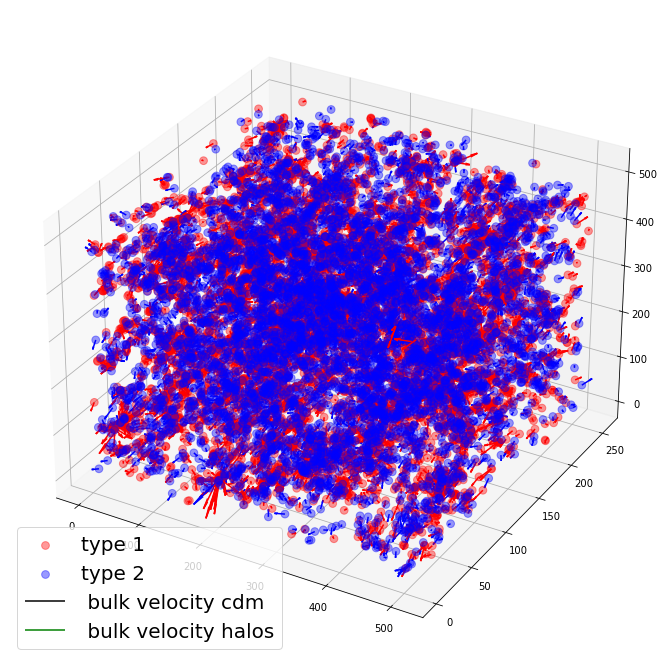

*****ngrid:1 is finished!***********
 *****simulation :lcdm is finished!*********** 


In [4]:

    
##################################
##################################
##################################
for number_smaples in [2]:  # How many sub-boxes

    print("****** computing for number of sub-boxes:"+str(number_smaples))
    for sim_size in ['L_512_N_256']:
        ##### parameters
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        obj = massive_neutrinos(boxsize);
        ### type of bulk species
        for bulk_species in ['cdm']:
            for snap_num in [3]: # the snapshot number start from high redshift
                for sim in ['lcdm']:
                    print("******sim:"+sim+" is being read!**************")
                    ######################
                    ## particles read
                    ######################
                    if bulk_species=='cdm':
                        print("bulk chosen to cdm")
                        snapshot = './../Simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                        #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                        ptype = [1]
                        cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                    ######################
                    ### Neutrinos read:
                    ######################
                    elif bulk_species=='nu':
                        print("bulk chosen to neutrino")
                        ptype=[1];
                        snapshot = './../Simulations//'+sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                        nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                    ######################
                    ## halo read
                    ######################
                    halo_address ='./../Simulations/'+sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                    #pop 1
                    halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                    data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                    data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                    #pop 2
                    halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                    data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                    data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                    #pop all
                    halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                    data_load[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                    data_load[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]
                    print("\033[32m number of halos: "+str(np.shape(halo_all)[0])+", number of p1: "+str(np.shape(halo_p1)[0])+", number of p2: "+str(np.shape(halo_p2)[0])+" \033[0m")
                    ##########

                    ##########
                    print("*****All files for sim:"+sim+" are read! Now we compute quantities in each sub-box ***********")

                    
                    for ngrid in range(0,2): 
                        if(number_smaples>ngrid*ngrid*ngrid):
                            number_smaples_tmp = ngrid*ngrid*ngrid;
                            print("\033[31m chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
                        else:
                            number_smaples_tmp = number_smaples;
                        sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
                        print(sub_box_lists)
                        ## Reseting the dictionary!
                        column_names = ['simulation','n_grid', 'sub_box_index','bulk_vel_halos_i', 'bulk_vel_cdm_i', 'vp1.v_b(cdm)', 'vp2.v_b(cdm)', 'vp1.v_b(halos)', 'vp2.v_b(halos)', 'v_h.v_b(cdm)','v_h.v_b(halos)']
                        df = pd.DataFrame(columns=column_names)
                        for i in range(number_smaples_tmp):
                            sub_box_index = sub_box_lists[i]
                            ##############################
                            ##### pcl velocities in each cell
                            ##############################
                            bulk_species = 'cdm'
                            pos_cdm = data_load[sim_size][sim][bulk_species]['pos']
                            vel_cdm = data_load[sim_size][sim][bulk_species]['vel']
                            cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### All halos velocities in each cell
                            ##############################
                            pos_halo_all = data_load[sim_size][sim]['halo']['pos']
                            vel_halo_all = data_load[sim_size][sim]['halo']['vel']
                            halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### Selecting two populations of halos and computing each 
                            ##### population velocities in each cell! 
                            ##############################
                            pos_halo_p1 =  data_load[sim_size][sim]['halo_p1']['pos'] 
                            vel_halo_p1 =  data_load[sim_size][sim]['halo_p1']['vel']
                            pos_halo_p2 =  data_load[sim_size][sim]['halo_p2']['pos']
                            vel_halo_p2 =  data_load[sim_size][sim]['halo_p2']['vel']
                            
                            halo_p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
                            halo_p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
                            
                            halo_p2_pos_i = obj.pos_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
                            halo_p1_pos_i = obj.pos_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
                            
                            if ( (np.shape(halo_p2_vels_i)[0]>0) and (np.shape(halo_p1_vels_i)[0])>0): # Only if we have halos from both population we do compute 

                                #############################
                                ### Bulk velocity computation
                                #############################
                                bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
                                bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm
                                
                                plot_sub_box(halo_p1_pos_i, halo_p1_vels_i/50, halo_p2_pos_i, halo_p2_vels_i/50, bulk_vel_cdm_i[0]/10, bulk_vel_halos_i[0]/10, 60)
#                                 ##############################
#                                 ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
#                                 ##############################
                                vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

                                vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

                                vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

                                data_saved = {
                                    'simulation':sim,
                                    'ngrid': ngrid,
                                    'sub_box_index': sub_box_index,
                                    'bulk_vel_halos_i': bulk_vel_halos_i,
                                    'bulk_vel_cdm_i': bulk_vel_cdm_i,
                                    'vp1.v_b(cdm)':vdvb_p1_bulk_cdm ,
                                    'vp2.v_b(cdm)':vdvb_p2_bulk_cdm ,
                                    'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                                    'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
                                    'v_h.v_b(cdm)':vdvb_all_bulk_cdm ,
                                    'v_h.v_b(halos)':vdvb_all_bulk_halos 
                                    }
#                                 df = df.append(data_saved, ignore_index=True)
#                         with open('./save_new/data_ngrid_'+str(ngrid)+'_sim_'+sim+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
#                             pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
                        print("*****ngrid:"+str(ngrid)+" is finished!***********")
                print("\033[34m *****simulation :"+sim+" is finished!*********** \033[0m")


## Test1: Let's check the number of sub-boxes and some sanity checks

 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:20
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:20


In [4]:
data_pop1=[]
data_pop2=[]

for number_smaples in [20]:  # How many sub-boxes
    for sim_size in ['L_512_N_256']:
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        for sim in ['Mn_0d6_nu_pcls','lcdm']:
            for ngrid in range(1,10,2): 
            # for ngrid in range(7,8,1): 

                if(number_smaples>ngrid*ngrid*ngrid):
                    number_smaples_tmp = ngrid*ngrid*ngrid;
                    print("\033[31m chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
                else:
                    number_smaples_tmp = number_smaples;
                file_path = './save_new//data_ngrid_'+str(ngrid)+'_sim_'+sim+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle';
                if os.path.exists(file_path):
                    with open(file_path,'rb') as handle:
                        df = pickle.load(handle)
                        if not df['bulk_vel_cdm_i'].empty:
                            vb = np.array([np.array(x) for x in df['bulk_vel_cdm_i']])[0]# The zeroth component picks the velocities the first component is the error!
                            vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself
                            avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for vb_dot_vb are more or less close to 1
                            std_vb_dot_vb = np.sqrt(np.average((vb_dot_vb - np.average(vb_dot_vb))**2))
                            # print()
                            #### population 1
                            weight = np.array([np.array(x) for x in df['vp1.v_b(cdm)']])[:,2] # number of halos in each sub-box
                            vector_vp1_dot_vb = np.array([np.array(x) for x in df['vp1.v_b(cdm)']])[:,0]
                            avg_vp1_dot_vb = np.average(vector_vp1_dot_vb, weights=weight, axis=0)
                            std_vp1_dot_vb=  np.average((vector_vp1_dot_vb - np.average(vector_vp1_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

                            #### population 2
                            weight = np.array([np.array(x) for x in df['vp2.v_b(cdm)']])[:,2] # number of halos in each sub-box
                            vector_vp2_dot_vb = np.array([np.array(x) for x in df['vp2.v_b(cdm)']])[:,0]
                            avg_vp2_dot_vb = np.average(vector_vp2_dot_vb, weights=weight, axis=0)
                            std_vp2_dot_vb=  np.average((vector_vp2_dot_vb - np.average(vector_vp2_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

                            # computing alpha_p1, alpha_p2
                            # std_alpha_p1 = (mu/nu)^2 * (std_mu^2/mu^2 + std_nu^2/nu^2) he ratio of two averages, alpha = mu/nu, can be thought of as the result of dividing two normal distributions. The variance of the ratio of two random variables is given by:
                            # Var(alpha) = (mu/nu)^2 * (Var(mu)/mu^2 + Var(nu)/nu^2 - 2 * Cov(mu,nu)/(mu*nu))
                            alpha_p1 = avg_vp1_dot_vb/avg_vb_dot_vb
                            var_alpha_p1 = (avg_vp1_dot_vb/avg_vb_dot_vb)**2 * (std_vp1_dot_vb**2/avg_vp1_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
                            std_alpha_p1 = np.sqrt(var_alpha_p1); 

                            # pop2:
                            alpha_p2 = avg_vp2_dot_vb/avg_vb_dot_vb
                            var_alpha_p2 = (avg_vp2_dot_vb/avg_vb_dot_vb)**2 * (std_vp2_dot_vb**2/avg_vp2_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
                            std_alpha_p2 = np.sqrt(var_alpha_p2); 
                            ### saving data:
                            dx = boxsize/ngrid;
                            data_pop1.append([dx,alpha_p1, std_alpha_p1, np.shape(vb)[0]])
                            data_pop2.append([dx,alpha_p2, std_alpha_p2, np.shape(vb)[0]]) # np.shape(vb)[0] shows the number of sub-boxes havebeen analyzed!

                        else:
                            print("\033[31m number sample: "+str(number_smaples)+", for ngrid: "+str(ngrid)+" is empty"+"\033[0m")
                    
                else:
                    print("\033[31m  Warning: File"+ file_path+" does not exist. \033[0m")

 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:20
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:20


In [8]:

import MAS_library as MASL
import numpy as np
import scipy
import h5py as h5
import matplotlib.pyplot as plt
import readgadget
from collections import defaultdict
from mpi4py import MPI
import random
import psutil
import os
import pandas as pd
import pickle


def nested_dict(n, type):
    """
    This function creates a nested dictionary with a specified depth and default value type.

    Parameters:
        n (int): an integer representing the depth of the nested dictionary.
        type: the default value type for the nested dictionary.

    Returns:
        A nested dictionary with a depth of 'n' and default values of the specified type.
    """
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
    
data_load = nested_dict(5, list)

class massive_neutrinos:
    """
    Class for massive neutrino project
    """
    def __init__(self, boxsize):
        self.comm = MPI.COMM_WORLD
        self.boxsize = boxsize;
        return


    def norm(self, x):
        """ norm of a vector """
        return np.sqrt(sum(x_i*x_i for x_i in x));


    def dist(self, x, y):
        """Distance of two points"""
        return self.norm(np.subtract(x,y)) ;

    def statistics(self, x):
        """Given a vector it returns the average and std of the list! """
        return (np.average(x),np.std(x));

    def halo_selection(self, data_address, string, mass_limit, extra_columns=False):
        """ outputting a halo population obtained by a mass limit and whether we want larger or smaller halos.
            input: data (halo catalogue from Rockstar), a string being + or -, and mass limit in solar mass.
            output: A new catalogue with [x,y,z,v_x,v_y,v_z] and additional columns of[Rvir,M200b] of halo population if requested!
        """
        data = np.loadtxt(data_address);
        if (string == "+"):
            condition = data[:,20]> mass_limit;
            if extra_columns:
                halo_pop = np.zeros((np.shape(data[condition])[0],8))
            else:
                halo_pop = np.zeros((np.shape(data[condition])[0],6))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[condition][:,5] # R_vir
                halo_pop[:,7] = data[condition][:,20] # Mass
        elif (string == "-"):
            condition = data[:,20]<= mass_limit;
            if extra_columns:
                halo_pop = np.zeros((np.shape(data[condition])[0],8))
            else:
                halo_pop = np.zeros((np.shape(data[condition])[0],6))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[condition][:,5] # R_vir
                halo_pop[:,7] = data[condition][:,20] # Mass
 
        elif (string == "all"):
            if extra_columns:
                halo_pop = np.zeros((np.shape(data)[0],8))
            else:
                halo_pop = np.zeros((np.shape(data)[0],6))
            for i in range(6):
                halo_pop[:,i] = data[:,8+i]
            if (extra_columns):
                halo_pop[:,6] = data[:,5] # R_vir
                halo_pop[:,7] = data[:,20] # Mass

        return halo_pop;

    def sum_vel_dot_vbulk(self, vel, velocity_bulk):
        """computing v_i . v_bulk for halos/particle using the bulk velocity and returning the sum of all dot product and number of halos in that cell."""
        # product = np.zeros((np.shape(vel)[0]));
        # # for i in range(np.shape(vel)[0]):
        # #     product += np.dot(vel[i,:], velocity_bulk) # velocity bulk is an 3D array while vel =  N_halos x 3
        avg = np.mean(np.dot(vel, velocity_bulk))
        std = np.std(np.dot(vel, velocity_bulk))
        return [avg, std, np.shape(vel)[0]] # returns sum of all dot product and number of halos in that cell

    def vels_in_cell(self, ngrid, pos, vel, sub_box_index):
        boxsize = self.boxsize;
        """outputting the velocity of halos in the given sub-box """
        condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
        condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
        condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
        condition_tot = (condition_x) & (condition_y) & (condition_z)
        vel_halos =vel[condition_tot];
        # pos_halos =pos[condition_tot]# For test you can output pos[vel_halos, pos_halos];
        return vel_halos

    def velocity_bulk(self, ngrid, pos,vel, sub_box_index):
        boxsize = self.boxsize;
        """computing the bulk velocity in a sub-box using the velocities of objects"""
        condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
        condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
        condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
        condition_tot = (condition_x) & (condition_y) & (condition_z)
        vel_grids= np.array([np.average(vel[condition_tot,0]),np.average(vel[condition_tot,1]),np.average(vel[condition_tot,2])])
        sigma_vel_grids= np.array([np.std(vel[condition_tot,0]),np.std(vel[condition_tot,1]),np.std(vel[condition_tot,2])])
        return [vel_grids,sigma_vel_grids];


    def catalogue_header(self, address, column=-1):
        """Takes the address of the halo catalogue and reads the whole header by default. If the column is specified then just prints the corresponding column!"""
        f = open(address)
        header = f.readline()
        header_list = header.split(' ') #list of columns
        if column==-1:
            for i in range(np.shape(header_list)[0]):
                print(str(i)+":"+header_list[i])
        if column!=-1:
            print(str(column)+":"+header_list[column])

    def gadget_load(self, snapshot, ptype=[1]):
        """Takes the address of the a gadget 2 snapshot and returns the pos and velocity of particles!
           input: snapshot address, ptype -- > [1] for cdm and [2] for neutrinos!
        """
        pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
        vel = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
        # ids = readgadget.read_block(snapshot, "ID  ", ptype)-1   #IDs starting from 0
        return np.array([pos,vel])


    # def Random_sub_box2(self, ngrid, number):
    #     """Takes the number of grids and return N randomly chosen sub-box indices!
    #     """
    #     res = np.zeros((number,3)).astype(int)
    #     for i in range(number):
    #         res[i] = random.sample(range(0, ngrid), 3)       
    #     return res
    
    def Random_sub_box(self, ngrid, number):
        """Takes the number of grids and return N randomly chosen sub-box indices!
        """
        res = np.zeros((number,3)).astype(int)
        for i in range(number):
            for j in range(3):
                res[i,j] = random.randint(0,ngrid-1)      
        return res


    def data_sub_boxes(self, sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x, y, z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx, vy, vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2, y_p2, z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2, vy_p2, vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        boxsize = self.boxsize;
        data=[]
        for i in range (np.shape(sub_box_lists)[0]):
            sub_box_index = sub_box_lists[i]
            bulk_vel = self.velocity_bulk(ngrid, pos_pcl,vel_pcl, sub_box_index); # Bulk velocity using cdm/neutrino
            vels_p1 = self.vels_in_cell(ngrid, pos_p1, vel_p1, sub_box_index);# velocity of population 1
            vels_p2 = self.vels_in_cell(ngrid, pos_p2, vel_p2, sub_box_index); # velocity of population 2
            # ## computing v_b.v_i information for two populations!
            vdvb_p1 = self.sum_vel_dot_vbulk(vels_p1, bulk_vel); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
            vdvb_p2 = self.sum_vel_dot_vbulk(vels_p2, bulk_vel);
            data.append([sub_box_index, vdvb_p1[0], vdvb_p2[0], vdvb_p1[1], vdvb_p2[1], vdvb_p1[2],  vdvb_p2[2]]);
            # [sub-box index, <v_i,v_b> population 1, <v_i,v_b> population 2, sigma v_i.v_b pop1, sigma v_i.v_b pop2, number of halos of pop1, number of halos of pop2]
        return data
    

    def Parallelized_alpha_sub_boxes(self, sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Parallelizing sub-boxes over number of CPUs and computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x,y,z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx,vy,vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2,y_p2,z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2,vy_p2,vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        comm = self.comm;
        boxsize = self.boxsize;
        rank = comm.Get_rank();
        size = comm.Get_size();
        t_start = MPI.Wtime()
        data=[]
        if rank == 0:
            a_row = sub_box_lists.shape[0]
            if a_row >= size:
                split = numpy.array_split(sub_box_lists, size, axis=0)
        else:
            split = None
        split = comm.scatter(split, root=0) # This scatters each part of vector over each CPU! The vector was initially produced based on number of CPUs.
        # split = numpy.dot(split, b)
        for i in range(np.shape(split)):
            sub_box_index = split[i];
            bulk_vel = velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index); # Bulk velocity using cdm/neutrino
            vels_p1 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index);# alpha for population 1
            vels_p2 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index); # alpha for population 2

            alphas_p1 = alpha_list(vels_p1, bulk_vel);
            alphas_p2 = alpha_list(vels_p2, bulk_vel);

            data.append(sub_box_index, np.average(alpha_p1), np.average(alpha_p2), np.std(alpha_p1), np.std(alpha_p2));
            # data containing sub-nox index, average of alpha_pi and std of alphas!

        data = comm.gather(data, root=0)
        if rank == 0:
            result = numpy.vstack(data)
            t_diff_multi = MPI.Wtime() - t_start    ### Stop stopwatch ###
            print('Time taken one core:', t_diff_one, 'Time taken one multicore:', t_diff_multi)
        return result

def memory():
    psutil.virtual_memory()
    # you can convert that object to a dictionary 
    dict(psutil.virtual_memory()._asdict())
    pid = os.getpid()
    python_process = psutil.Process(pid)
    # you can have the percentage of used RAM
    memoryUse = python_process.memory_info()[0]/2.**30  # memory use in GB...I think
    print('memory use:', memoryUse, 'GB, percentage: ',psutil.virtual_memory().percent)
    
    
    
##################################
##################################
##################################
for number_smaples in [20]:  # How many sub-boxes

    print("****** computing for number of sub-boxes:"+str(number_smaples))
    for sim_size in ['L_512_N_256']:
        ##### parameters
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        obj = massive_neutrinos(boxsize);
        ### type of bulk species
        for bulk_species in ['cdm']:
            for snap_num in [3]: # the snapshot number start from high redshift
                for sim in ['Mn_0d6_nu_pcls','lcdm']:
                    print("******sim:"+sim+" is being read!**************")
                    ######################
                    ## particles read
                    ######################
                    if bulk_species=='cdm':
                        print("bulk chosen to cdm")
                        snapshot = './../Simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                        #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                        ptype = [1]
                        cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                    ######################
                    ### Neutrinos read:
                    ######################
                    elif bulk_species=='nu':
                        print("bulk chosen to neutrino")
                        ptype=[1];
                        snapshot = './../Simulations//'+sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                        nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                    ######################
                    ## halo read
                    ######################
                    halo_address ='./../Simulations/'+sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                    #pop 1
                    halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                    data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                    data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                    #pop 2
                    halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                    data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                    data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                    #pop all
                    halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                    data_load[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                    data_load[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]
                    print("\033[32m number of halos: "+str(np.shape(halo_all)[0])+", number of p1: "+str(np.shape(halo_p1)[0])+", number of p2: "+str(np.shape(halo_p2)[0])+" \033[0m")
                    ##########

                    ##########
                    print("*****All files for sim:"+sim+" are read! Now we compute quantities in each sub-box ***********")

                    
                    for ngrid in range(1,10,2): 
                        if(number_smaples>ngrid*ngrid*ngrid):
                            number_smaples_tmp = ngrid*ngrid*ngrid;
                            print("\033[31m chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
                        else:
                            number_smaples_tmp = number_smaples;
                        sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
                        ## Reseting the dictionary!
                        column_names = ['simulation','n_grid', 'sub_box_index','bulk_vel_halos_i', 'bulk_vel_cdm_i', 'vp1.v_b(cdm)', 'vp2.v_b(cdm)', 'vp1.v_b(halos)', 'vp2.v_b(halos)', 'v_h.v_b(cdm)','v_h.v_b(halos)']
                        df = pd.DataFrame(columns=column_names)
                        for i in range(number_smaples_tmp):
                            sub_box_index = sub_box_lists[i]
                            ##############################
                            ##### pcl velocities in each cell
                            ##############################
                            bulk_species = 'cdm'
                            pos_cdm = data_load[sim_size][sim][bulk_species]['pos']
                            vel_cdm = data_load[sim_size][sim][bulk_species]['vel']
                            cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### All halos velocities in each cell
                            ##############################
                            pos_halo_all = data_load[sim_size][sim]['halo']['pos']
                            vel_halo_all = data_load[sim_size][sim]['halo']['vel']
                            halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

                            ##############################
                            ##### Selecting two populations of halos and computing each 
                            ##### population velocities in each cell! 
                            ##############################
                            pos_halo_p1 =  data_load[sim_size][sim]['halo_p1']['pos'] 
                            vel_halo_p1 =  data_load[sim_size][sim]['halo_p1']['vel']
                            pos_halo_p2 =  data_load[sim_size][sim]['halo_p2']['pos']
                            vel_halo_p2 =  data_load[sim_size][sim]['halo_p2']['vel']
                            halo_p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
                            halo_p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
                            if ( (np.shape(halo_p2_vels_i)[0]>0) and (np.shape(halo_p1_vels_i)[0])>0): # Only if we have halos from both population we do compute 

                                #############################
                                ### Bulk velocity computation
                                #############################
                                bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
                                bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm

                                ##############################
                                ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
                                ##############################
                                vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

                                vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

                                vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                                vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

                                data_saved = {
                                    'simulation':sim,
                                    'ngrid': ngrid,
                                    'sub_box_index': sub_box_index,
                                    'bulk_vel_halos_i': bulk_vel_halos_i,
                                    'bulk_vel_cdm_i': bulk_vel_cdm_i,
                                    'vp1.v_b(cdm)':vdvb_p1_bulk_cdm ,
                                    'vp2.v_b(cdm)':vdvb_p2_bulk_cdm ,
                                    'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                                    'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
                                    'v_h.v_b(cdm)':vdvb_all_bulk_cdm ,
                                    'v_h.v_b(halos)':vdvb_all_bulk_halos 
                                    }
                                df = df.append(data_saved, ignore_index=True)
                        with open('./save_new/data_ngrid_'+str(ngrid)+'_sim_'+sim+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
                            pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
                        print("*****ngrid:"+str(ngrid)+" is finished!***********")
                print("\033[34m *****simulation :"+sim+" is finished!*********** \033[0m")


[14  7 13]
15


In [7]:
##################################
##################################
##################################
for number_smaples in [20]:  # How many sub-boxes

    print("****** computing for number of sub-boxes:"+str(number_smaples))
    for sim_size in ['L_512_N_256']:
        ##### parameters
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        obj = massive_neutrinos(boxsize);
        ### type of bulk species
        for bulk_species in ['cdm']:
            for snap_num in [3]: # the snapshot number start from high redshift
                for sim in ['Mn_0d6_nu_pcls']:
                    print("******sim:"+sim+" is being read!**************")
                    ######################
                    ## particles read
                    ######################
                    if bulk_species=='cdm':
                        print("bulk chosen to cdm")
                        snapshot = './../Simulations///'+sim_size+'/'+sim+'/output/snap00'+str(snap_num)+'_cdm'
                        #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
                        ptype = [1]
                        cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = cdm_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = cdm_pcl[1];
                    ######################
                    ### Neutrinos read:
                    ######################
                    elif bulk_species=='nu':
                        print("bulk chosen to neutrino")
                        ptype=[1];
                        snapshot = './../Simulations//'+sim_size+'//'+sim+'/output/snap00'+str(snap_num)+'_ncdm0'
                        nu_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
                        data_load[sim_size][sim][bulk_species]['pos'] = nu_pcl[0]; 
                        data_load[sim_size][sim][bulk_species]['vel'] = nu_pcl[1];
                    ######################
                    ## halo read
                    ######################
                    halo_address ='./../Simulations/'+sim_size+'/'+sim+'/output/halos/out_'+str(snap_num)+'.list'
                    #pop 1
                    halo_p1 = obj.halo_selection(halo_address, '+', mass_limit);
                    data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
                    data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
                    #pop 2
                    halo_p2 = obj.halo_selection(halo_address, '-', mass_limit)
                    data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
                    data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
                    #pop all
                    halo_all = obj.halo_selection(halo_address, 'all', mass_limit)
                    data_load[sim_size][sim]['halo']['pos'] = halo_all[:,:3]
                    data_load[sim_size][sim]['halo']['vel'] = halo_all[:,3:6]
                    print("\033[32m number of halos: "+str(np.shape(halo_all)[0])+", number of p1: "+str(np.shape(halo_p1)[0])+", number of p2: "+str(np.shape(halo_p2)[0])+" \033[0m")
                    ##########

****** computing for number of sub-boxes:20
******sim:Mn_0d6_nu_pcls is being read!**************
bulk chosen to cdm
 number of halos: 9731, number of p1: 4653, number of p2: 5078 


In [8]:
data_load[sim_size][sim][bulk_species]['vel']

array([[-505.9769  , -221.71313 ,  101.902405],
       [-382.73206 , -246.3043  ,  145.18205 ],
       [-292.889   , -239.32129 ,  126.41543 ],
       ...,
       [-571.40704 , -157.66046 ,   32.70515 ],
       [-337.02353 , -195.72679 ,  135.51183 ],
       [-635.25684 , -112.5592  ,   36.89306 ]], dtype=float32)

In [10]:
data_load[sim_size][sim]['halo_p1']['vel']

array([[-1278.79, -1519.71,  1193.49],
       [  286.94,  -104.65,  -187.63],
       [  169.52,  1510.35,   849.43],
       ...,
       [ -308.83,   258.96,   -93.58],
       [  228.29,   486.41,    48.64],
       [  377.74,    73.16,   409.34]])

# Computing alphas

In [75]:
%%time
memory();

##########
number_smaples = 5;
sim_size = 'L_512_N_256'
sim = 'Mn_0d6_nu_pcls'
nu_consider = "yes"
##########

column_names = ['simulation','n_grid', 'sub_box_index','bulk_vel_halos_i', 'bulk_vel_cdm_i', 'vp1.v_b(cdm)', 'vp2.v_b(cdm)', 'vp1.v_b(halos)', 'vp2.v_b(halos)']
df = pd.DataFrame(columns=column_names)
##########

    for ngrid in [10, 4]:
        sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
        for i in range(number_smaples):
            sub_box_index = sub_box_lists[i]
            ##############################
            ##### pcl velocities in each cell
            ##############################
            bulk_species = 'cdm'
            pos_cdm = data_load[sim_size][sim][bulk_species]['pos']
            vel_cdm = data_load[sim_size][sim][bulk_species]['vel']
            cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

            ##############################
            ##### All halos velocities in each cell
            ##############################
            pos_halo_all = data_load[sim_size][sim]['halo']['pos']
            vel_halo_all = data_load[sim_size][sim]['halo']['vel']
            halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!

            ##############################
            ##### Selecting two populations of halos and computing each 
            ##### population velocities in each cell! 
            ##############################
            pos_halo_p1 =  data_load[sim_size][sim]['halo_p1']['pos'] 
            vel_halo_p1 =  data_load[sim_size][sim]['halo_p1']['vel']
            pos_halo_p2 =  data_load[sim_size][sim]['halo_p2']['pos']
            vel_halo_p2 =  data_load[sim_size][sim]['halo_p2']['vel']
            halo_p2_vels_i = obj.vels_in_cell(ngrid, pos_halo_p2, vel_halo_p2, sub_box_index)
            halo_p1_vels_i = obj.vels_in_cell(ngrid, pos_halo_p1, vel_halo_p1, sub_box_index)
            if ( (np.shape(halo_p2_vels_i)[0]>0) and (np.shape(halo_p1_vels_i)[0])>0): # Only if we have halos from both population we do compute 

                #############################
                ### Bulk velocity computation
                #############################
                bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index) # Bulk velocities using halos
                bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index) # Bulk velocities using cdm

                ##############################
                ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
                ##############################
                vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

                vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
                vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);


                data_saved = {
                    'simulation':sim,
                    'ngrid': ngrid,
                    'sub_box_index': sub_box_index,
                    'bulk_vel_halos_i': bulk_vel_halos_i,
                    'bulk_vel_cdm_i': bulk_vel_cdm_i,
                    'vp1.v_b(cdm)':vdvb_p1_bulk_cdm ,
                    'vp2.v_b(cdm)':vdvb_p2_bulk_cdm ,
                    'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                    'vp2.v_b(halos)':vdvb_p2_bulk_halos
                    }
                df = df.append(data_saved, ignore_index=True)
                with open('data_ngrid_'+str(ngrid)+'.pickle', 'wb') as handle:
                    pickle.dump(data_saved, handle, protocol=pickle.HIGHEST_PROTOCOL)
# To have access to bulk velocities: df['[bulk_vel_halos_i, sigma]'][:6][0][0]        
# To have access to the sub-box index of when ngrid = 10, df[df['ngrid']==10]['sub_box_index']
# print(df.loc[df['ngrid'] == 20]['velocities'].values)
#  np.array([np.array(x) for x in df[df['ngrid']==10]['bulk_vel_cdm_i']])
# np.average(df[df['ngrid']==10]['vp1.v_b(cdm)'].apply(lambda x: x[0]))
# Example of computing alpha 
#velocity_bulk = np.array([np.array(x) for x in df[df['ngrid']==10]['bulk_vel_cdm_i']])[0]# The zeroth component picks the velocities the first component is the error!
# vbdvb = np.einsum('ij,ij->i', velocity_bulk, velocity_bulk) # dot product of v_bulk vectors with itself
# alpha = np.average(df[df['ngrid']==10]['vp1.v_b(cdm)'].apply(lambda x: x[0]))/np.average(vbdvb)
# alpha


memory use: 1.0148200988769531 GB, percentage:  8.8
CPU times: user 3.98 s, sys: 950 ms, total: 4.93 s
Wall time: 4.93 s


In [77]:
for ngrid in [10, 4]:
    with open('data_ngrid_'+str(ngrid)+'.pickle', 'rb') as handle:
        loaded_data = pickle.load(handle)
        print(loaded_data)

{'simulation': 'Mn_0d6_nu_pcls', 'ngrid': 10, 'sub_box_index': array([1, 4, 5]), 'bulk_vel_halos_i': [array([54.701 , 54.716 ,  5.2085]), array([157.9234518 , 147.5413921 , 244.43771915])], 'bulk_vel_cdm_i': [array([28.887142, 15.795586, 37.99462 ], dtype=float32), array([180.10384, 176.58476, 209.0152 ], dtype=float32)], 'vp1.v_b(cdm)': [7889.01138278961, 10063.2689252042, 6], 'vp2.v_b(cdm)': [393.7405685806276, 7071.445792817316, 14], 'vp1.v_b(halos)': [2138.8505425, 12599.777690775609, 6], 'vp2.v_b(halos)': [7673.590523571429, 13103.359790090115, 14]}
{'simulation': 'Mn_0d6_nu_pcls', 'ngrid': 4, 'sub_box_index': array([1, 0, 2]), 'bulk_vel_halos_i': [array([ 86.90414365, 121.47472376, 109.38914365]), array([288.73257227, 280.71305295, 309.31255058])], 'bulk_vel_cdm_i': [array([104.53278, 117.23321,  77.3088 ], dtype=float32), array([277.51465, 268.66144, 281.95667], dtype=float32)], 'vp1.v_b(cdm)': [33216.45894754269, 46450.28276857139, 190], 'vp2.v_b(cdm)': [30197.31161412261, 4369

In [73]:
loaded_data

{'simulation': 'Mn_0d6_nu_pcls',
 'ngrid': 4,
 'sub_box_index': array([3, 0, 1]),
 'bulk_vel_halos_i': [array([ -49.00790441,   33.23198529, -142.25040441]),
  array([263.53772128, 238.8862163 , 244.3550822 ])],
 'bulk_vel_cdm_i': [array([ -42.62286 ,   15.237506, -129.62643 ], dtype=float32),
  array([250.8082 , 236.80194, 233.40672], dtype=float32)],
 'vp1.v_b(cdm)': [19968.26832458433, 33871.545659562085, 135],
 'vp2.v_b(cdm)': [22085.448820148038, 32019.342862617035, 137],
 'vp1.v_b(halos)': [22694.544230571897, 37889.59441568437, 135],
 'vp2.v_b(halos)': [24772.808607181196, 36482.91261857934, 137]}

In [56]:
velocity_bulk = np.array([np.array(x) for x in df[df['ngrid']==10]['bulk_vel_cdm_i']])[0]
# velocity_bulk.shape
# np.einsum('ij,ij->i', velocity_bulk, velocity_bulk)

In [59]:
velocity_bulk = np.array([np.array(x) for x in df[df['ngrid']==10]['bulk_vel_cdm_i']])[0]# The zeroth component picks the velocities the first component is the error!
vbdvb = np.einsum('ij,ij->i', velocity_bulk, velocity_bulk) # dot product of v_bulk vectors with itself
alpha = np.average(df[df['ngrid']==10]['vp1.v_b(cdm)'].apply(lambda x: x[0]))/np.average(vbdvb)
alpha

0.6367177999421827

In [38]:
v_b = df[df['ngrid']==10]['bulk_vel_cdm_i']
# np.dot(v_b, v_b)
# vectors = np.vstack(v_b[0]) 
v_b

0    [[-98.41305, 272.8686, 26.768887], [190.3833, ...
1    [[255.53531, -176.89328, 51.733227], [167.6031...
Name: bulk_vel_cdm_i, dtype: object

In [36]:
arr = np.array([np.array(x) for x in df[df['ngrid']==10]['bulk_vel_cdm_i']])

In [47]:
vectors = [[1,1,1],
          [2,2,2]]
dot_products = np.einsum('ij,ij->i', vectors, vectors)

In [54]:
arr[0]

array([[-98.41305 , 272.8686  ,  26.768887],
       [190.3833  , 198.50374 , 197.43755 ]], dtype=float32)

In [34]:
vectors

array([[-98.41305 , 272.8686  ,  26.768887],
       [190.3833  , 198.50374 , 197.43755 ]], dtype=float32)

In [38]:
# alphas = df[df['ngrid']==10]['vp1.v_b(cdm)']
first_column_np=np.array(df[df['ngrid']==10]['vp1.v_b(cdm)'])[:,0]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [31]:
df.keys()

Index(['simulation', 'n_grid', 'sub_box_index', '[bulk_vel_halos_i, sigma]',
       '[bulk_vel_cdm_i, sigma]', '[<vp1.v_b(cdm)>, s, number]',
       '[<vp2.v_b(cdm)>, s, number]', '[<vp1.v_b(halos)>, s, number]',
       '[<vp2.v_b(halos)>, s, number]', 'ngrid'],
      dtype='object')

In [44]:
%%time
memory();

##########
number_smaples = 25;
sim_size = 'L_512_N_256'
sim = 'Mn_0d6_nu_pcls'
nu_consider = "yes"
##########

weight_tot=0;
alpha_halos_nu_tmp = 0
vb_dot_vb_nu = 0
alpha_halos_cdm_tmp = 0
alpha_halos_cdm=0;
alpha_halos_cdm_weighted=0;
alpha_halos_cdm_tmp_weighted=0;
alpha_halos_nu_cdm=0;
vb_dot_vb_cdm=0;
alpha_halos_cdm=0;
alpha_halos_cdm_v1 = 0
alpha_halos_nu_v1 = 0
alpha_halos_halos_tmp=0
alpha_halos_halos_tmp_weighted=0
vb_dot_vb_halos=0
alpha_halos_halos=0
alpha_halos_halos_weighted=0
alpha_halos_nu_tmp_weighted=0
for ngrid in [10]:
    ####
    # alpha_halos_nu=[]
    # alpha_cdm_nu=[]
    # alpha_halos_halos=[]
    bulk_vel_cdm=[]
    bulk_vel_nu=[]
    bulk_vel_halos=[];
    ####
    vel_dot_vbulk_array=[]
    ####
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    for i in range(number_smaples):
        sub_box_index = sub_box_lists[i]
        ##############################
        ##### pcl velocities in each cell
        ##############################
        bulk_species = 'cdm'
        pos_cdm = data[sim_size][sim][bulk_species]['pos']
        vel_cdm = data[sim_size][sim][bulk_species]['vel']
        cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        
        ##############################
        ##### nu velocities in each cell
        ##############################
        if nu_consider == "yes":
            bulk_species = 'nu'
            pos_nu = data[sim_size][sim][bulk_species]['pos']
            vel_nu = data[sim_size][sim][bulk_species]['vel']
            nu_vels = obj.vels_in_cell(ngrid, pos_nu, vel_nu, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
       
        ##### halos velocities in each cell
        pos_halo_all = data[sim_size][sim]['halo']['pos']
        vel_halo_all = data[sim_size][sim]['halo']['vel']
        halos_vels_i = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # print(halos_vels)
        
        #### Bulk velocity computation
        bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos_halo_all, vel_halo_all, sub_box_index)
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm, vel_cdm, sub_box_index)
        
        ### all bulk velocities!
        bulk_vel_cdm.append([ngrid, sub_box_index,bulk_vel_cdm_i] ) # gives the bulk velocity and its 1 sigma as an array!
        bulk_vel_halos.append([ngrid, sub_box_index, bulk_vel_halos_i] ) # gives the bulk velocity and its 1 sigma as an array!

        if nu_consider == "yes":
            bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu, vel_nu, sub_box_index)
            bulk_vel_nu.append([ngrid, sub_box_index, bulk_vel_nu_i]) # gives the bulk velocity and its 1 sigma as an array!

        

        ## computing alpha using just np.dot(vel[i,:], velocity_bulk[0])/np.dot(velocity_bulk[0],velocity_bulk[0]) in each cell!
        alpha_halos_cdm_v1 = alpha_halos_cdm_v1 + np.average(obj.alpha_list(halos_vels_i, bulk_vel_cdm_i))
        alpha_halos_nu_v1 = alpha_halos_nu_v1 + np.average(obj.alpha_list(halos_vels_i, bulk_vel_nu_i));

        ## computing v_i.v_bulk for each cell and sum over all cells at the end and divide by b_b.v_b
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[0][0];
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_nu_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_nu_tmp = alpha_halos_nu_tmp +  tmp;
            alpha_halos_nu_tmp_weighted = alpha_halos_nu_tmp_weighted +  tmp * weight;
            
            # weight_tot_nu = weight_tot +  weight; 
            vb_dot_vb_nu = vb_dot_vb_nu +  np.dot(bulk_vel_nu_i[0],bulk_vel_nu_i[0])*weight;
            
        #### cdm halos
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[0][0];
            
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_cdm_tmp = alpha_halos_cdm_tmp + tmp;
            alpha_halos_cdm_tmp_weighted = alpha_halos_cdm_tmp_weighted +  tmp * weight;
            weight_tot_cdm = weight_tot +  weight; 
            vb_dot_vb_cdm = vb_dot_vb_cdm +  np.dot(bulk_vel_cdm_i[0],bulk_vel_cdm_i[0])*weight;
            print("v_i.v_b/v_b.v_b=",tmp/np.dot(bulk_vel_cdm_i[0],bulk_vel_cdm_i[0]))
            
            
        #### halos halos
        if (obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1] != 0):
            print("num=",obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1])
            tmp = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[0][0];
            num_pop = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0])[1]
            ######
            weight = num_pop;
            alpha_halos_halos_tmp = alpha_halos_halos_tmp + tmp;
            alpha_halos_halos_tmp_weighted = alpha_halos_halos_tmp_weighted +  tmp * weight;
            weight_tot_h = weight_tot +  weight; 
            vb_dot_vb_halos = vb_dot_vb_halos +  np.dot(bulk_vel_halos_i[0],bulk_vel_halos_i[0])*weight;
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_cdm.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_cdm_i)]);
        # alpha_halos_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_nu_i)]);
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_p1_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p1, bulk_vel_cdm)]);
        # alpha_halos_p2_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p2, bulk_vel_cdm)]);

    alpha_halos_nu = alpha_halos_nu_tmp/vb_dot_vb_nu;
    alpha_halos_nu_weighted = alpha_halos_nu_tmp_weighted/vb_dot_vb_nu;

    alpha_halos_cdm = alpha_halos_cdm_tmp/vb_dot_vb_cdm;
    alpha_halos_cdm_weighted = alpha_halos_cdm_tmp_weighted/vb_dot_vb_cdm;
 
    alpha_halos_halos = alpha_halos_halos_tmp/vb_dot_vb_halos;
    alpha_halos_halos_weighted = alpha_halos_halos_weighted/vb_dot_vb_halos;

    # print('alpha_FH(halos, nu) = ',alpha_halos_nu);
    # print('alpha_FH(halos, cdm) = ',alpha_halos_cdm_v1);

    # print('alpha_wighted(halos, nu) = ',alpha_halos_nu_weighted);
    print('alpha(halos, nu) = ',alpha_halos_nu);
    print('alpha_wighted(halos, nu) = ',alpha_halos_nu_weighted);

    print('alpha(halos, cdm) = ',alpha_halos_cdm);
    print('alpha_wighted(halos, cdm) = ',alpha_halos_cdm_weighted);

    print('alpha(halos, cdm) = ',alpha_halos_cdm);
    print('alpha_wighted(halos, cdm) = ',alpha_halos_cdm_weighted);


memory use: 1.2865447998046875 GB, percentage:  9.2
num= 32
num= 32
v_i.v_b/v_b.v_b= 0.8445409781932689
num= 32
num= 5
num= 5
v_i.v_b/v_b.v_b= 1.0580763611886688
num= 5
num= 8
num= 8
v_i.v_b/v_b.v_b= 0.18846056734383368
num= 8
num= 17
num= 17
v_i.v_b/v_b.v_b= 1.3086147436756217
num= 17
num= 8
num= 8
v_i.v_b/v_b.v_b= 0.9163254482243993
num= 8
num= 18
num= 18
v_i.v_b/v_b.v_b= 0.7619221440561309
num= 18
num= 31
num= 31
v_i.v_b/v_b.v_b= 0.8983026424912793
num= 31
num= 23
num= 23
v_i.v_b/v_b.v_b= 0.8787950053483785
num= 23
num= 23
num= 23
v_i.v_b/v_b.v_b= 0.7496360100881883
num= 23
num= 63
num= 63
v_i.v_b/v_b.v_b= 1.0170666422588
num= 63
num= 19
num= 19
v_i.v_b/v_b.v_b= 1.0044469080290277
num= 19
num= 12
num= 12
v_i.v_b/v_b.v_b= 1.1477345348937293
num= 12
num= 16
num= 16
v_i.v_b/v_b.v_b= 0.900867168296654
num= 16
alpha(halos, nu) =  0.042891232631182476
alpha_wighted(halos, nu) =  0.9773632926500778
alpha(halos, cdm) =  0.040870294299824236
alpha_wighted(halos, cdm) =  0.919514331207126
alp

In [51]:
number_smaples = 10;
ngrid= 5
sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
sub_box_lists
pos_pcl = data[sim_size][sim][bulk_species]['pos']
vel_pcl = data[sim_size][sim][bulk_species]['vel']
pos_p1 =  pos_halo_all
vel_p1 =  vel_halo_all
vel_p2 = vel_p1
pos_p2 = pos_p1

In [ ]:
def Parallelized_alpha_sub_boxes(sub_box_lists, ngrid, pos_pcl, vel_pcl, pos_p1, vel_p1, pos_p2, vel_p2):
        """
        Parallelizing sub-boxes over number of CPUs and computing alpha and sigma_alpha for each sub-box -- returning all alphas for number of sub-boxes!
        Input: 
        - index of sub-boxes we want to consider!
        - ngrid :  Number of grids = the resolution we want to compute alpha over.
        - pos of particles we want to compute the bulk velocity from  -- N x 3 array containing x, y, z of pcls
        - vel of particles we want to compute the bulk velocity from -- N x 3 array containing v_x, v_y, v_z 
        - pos_p1: position of halo population 1, N_p1 x 3 array containing [x,y,z] for population 1
        - vel_p1: position of halo population 1, N_p1 x 3 array containing [vx,vy,vz] for population 1
        - pos_p2: position of halo population 2, N_p1 x 3 array containing [x_p2,y_p2,z_p2] for population 1
        - vel_p2: velocity of halo population 2, N_p1 x 3 array containing [vx_p2,vy_p2,vz_p2] for population 1
        output:
        - An array containing [index of sub-box, average of alpha, std of alpha]
        """
        comm = self.comm;
        boxsize = self.boxsize;
        rank = comm.Get_rank();
        size = comm.Get_size();
        t_start = MPI.Wtime()
        data=[]
        if rank == 0:
            a_row = sub_box_lists.shape[0]
            if a_row >= size:
                split = numpy.array_split(sub_box_lists, size, axis=0)
        else:
            split = None
        split = comm.scatter(split, root=0) # This scatters each part of vector over each CPU! The vector was initially produced based on number of CPUs.
        # split = numpy.dot(split, b)
        for i in range(np.shape(split)):
            sub_box_index = split[i];
            bulk_vel = velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index); # Bulk velocity using cdm/neutrino
            vels_p1 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index);# alpha for population 1
            vels_p2 = vels_in_cell(ngrid, boxsize, pos, vel, sub_box_index); # alpha for population 2

            alphas_p1 = alpha_list(vels_p1, bulk_vel);
            alphas_p2 = alpha_list(vels_p2, bulk_vel);

            data.append(sub_box_index, np.average(alpha_p1), np.average(alpha_p2), np.std(alpha_p1), np.std(alpha_p2));
            # data containing sub-nox index, average of alpha_pi and std of alphas!

        data = comm.gather(data, root=0)
        if rank == 0:
            result = numpy.vstack(data)
            t_diff_multi = MPI.Wtime() - t_start    ### Stop stopwatch ###
            print('Time taken one core:', t_diff_one, 'Time taken one multicore:', t_diff_multi)
        return result

## Printing velocities in each cell

## Histogram of positions and velocities of species

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


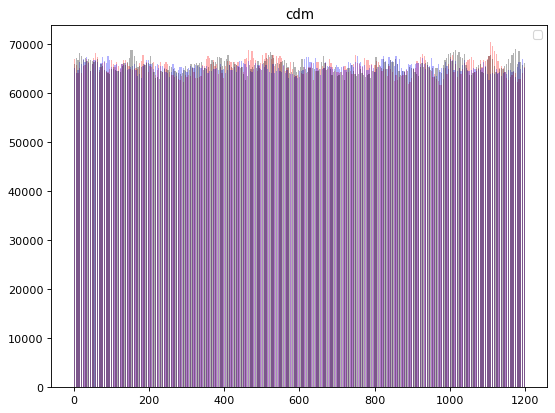

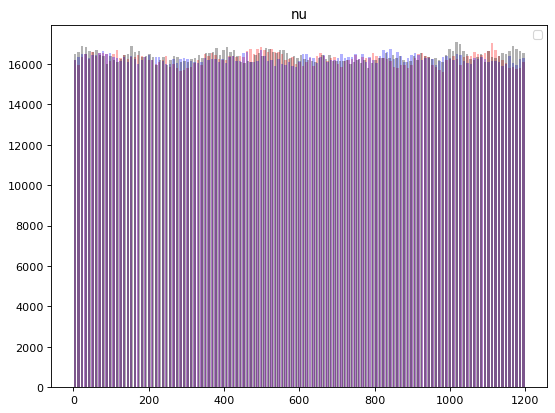

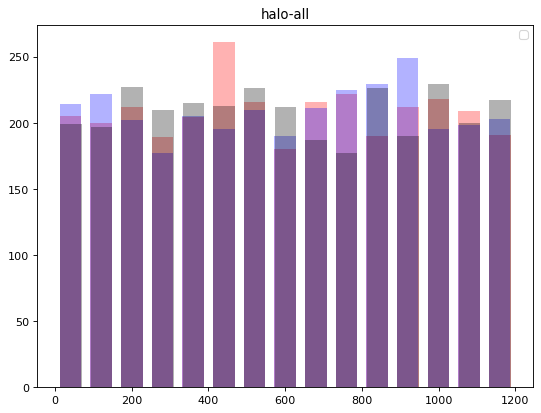

In [17]:
from matplotlib.pyplot import figure


# counts, bins = np.histogram(pos_cdm[:,0], bins=12)
# plt.hist(pos_cdm[:,0], bins, alpha=1)
labels = ['cdm', 'nu', 'halo-all']
l=0
for x in [pos_cdm, pos_nu, pos_halo_all]:
    figure(figsize=(8, 6), dpi=80)
    plt.hist(x=x[:,0], bins='auto', color='red',
                                alpha=0.3, rwidth=0.7)
    plt.hist(x=x[:,1], bins='auto', color='blue',
                                alpha=0.3, rwidth=0.7)
    plt.hist(x=x[:,2], bins='auto', color='black',
                                alpha=0.3, rwidth=0.7)
    # plt.legend()
    plt.title(labels[l])
    l=l+1

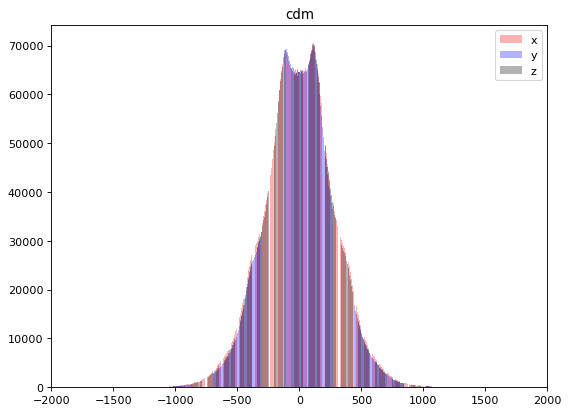

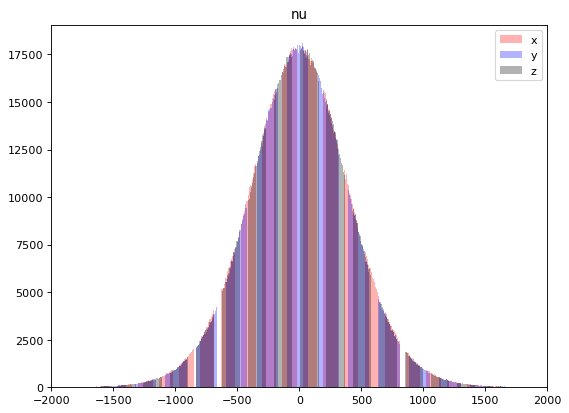

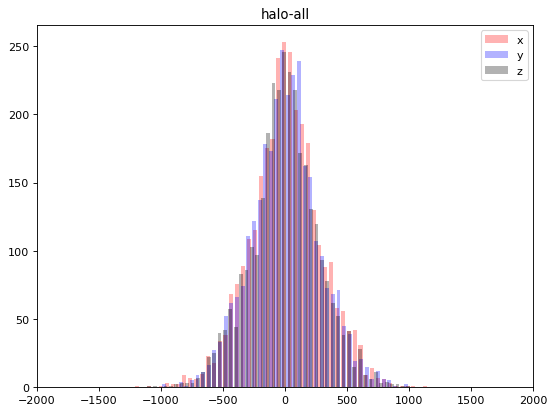

In [32]:
from matplotlib.pyplot import figure


# counts, bins = np.histogram(pos_cdm[:,0], bins=12)
# plt.hist(pos_cdm[:,0], bins, alpha=1)
labels = ['cdm', 'nu', 'halo-all']
l=0
for x in [vel_cdm, vel_nu, vel_halo_all]:
    figure(figsize=(8, 6), dpi=80)
    plt.hist(x=x[:,0], bins='auto', color='red',
                                alpha=0.3, rwidth=0.7,label="x")
    plt.hist(x=x[:,1], bins='auto', color='blue',
                              alpha=0.3, rwidth=0.7,label="y")
    plt.hist(x=x[:,2], bins='auto', color='black',
                                alpha=0.3, rwidth=0.7,label="z")
    plt.legend()
    plt.xlim(-2000,2000)
    plt.title(labels[l])
    l=l+1

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


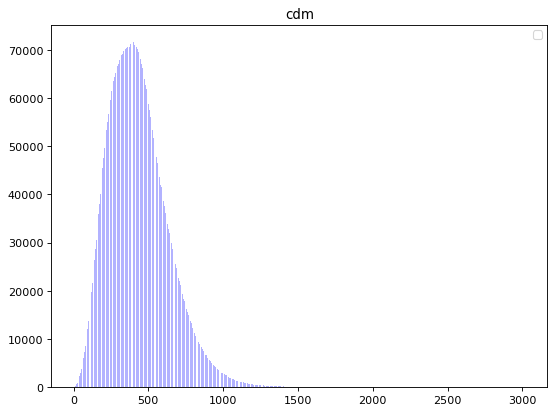

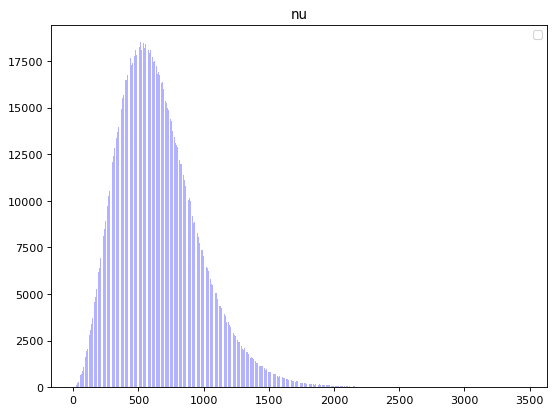

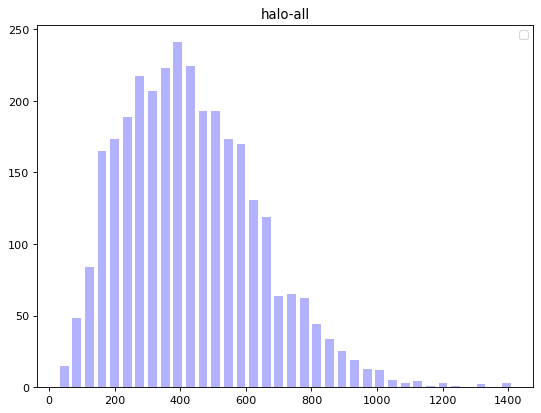

In [9]:
from matplotlib.pyplot import figure


# counts, bins = np.histogram(pos_cdm[:,0], bins=12)
# plt.hist(pos_cdm[:,0], bins, alpha=1)
labels = ['cdm', 'nu', 'halo-all']
l=0
for x in [vel_cdm, vel_nu, vel_halo_all]:
    figure(figsize=(8, 6), dpi=80)
    plt.hist(x=np.sqrt(x[:,0]**2+x[:,1]**2+x[:,2]**2), bins='auto', color='blue',
                                alpha=0.3, rwidth=0.7)
    # plt.hist(x=x[:,1], bins='auto', color='blue',
    #                             alpha=0.3, rwidth=0.7,label="y")
    # plt.hist(x=x[:,2], bins='auto', color='black',
    #                             alpha=0.3, rwidth=0.7,label="z")
    plt.legend()
    # plt.xlim(-2000,2000)
    plt.title(labels[l])
    l=l+1

In [13]:
%%time
memory();

number_smaples = 10;

for ngrid in [20]:
    alpha_halos_cdm=[]
    alpha_halos_nu=[]
    alpha_cdm_nu=[]
    ##
    bulk_vel_cdm=[]
    bulk_vel_nu=[]
    alpha_halos_cdm=[]
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    for i in range(number_smaples):
        sub_box_index = sub_box_lists[i]
        ##### pcl velocities in each cell
        pos_pcl = data[sim_size][sim][bulk_species]['pos']
        vel_pcl = data[sim_size][sim][bulk_species]['vel']
        cdm_vels = obj.vels_in_cell(ngrid, pos_pcl, vel_pcl, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        
        ##### halos velocities in each cell
        pos_halo_all = data[sim_size][sim]['halo']['pos']
        vel_halo_all = data[sim_size][sim]['halo']['vel']
        halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # print(halos_vels)
        
        #### Bulk velocity computation
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm,vel_cdm, sub_box_index)
        bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu,vel_nu, sub_box_index)
        
        bulk_vel_cdm .append([ngrid, sub_box_index,bulk_vel_cdm_i] ) # gives the bulk velocity and its 1 sigma as an array!
        bulk_vel_nu.append([ngrid, sub_box_index,bulk_vel_nu_i] ) # gives the bulk velocity and its 1 sigma as an array!
            
        # alpha_halos_cdm.append([ngrid, sub_box_index, obj.alpha_list(vel_halo_all, bulk_vel_cdm_i)]);
        # alpha_halos_nu.append([ngrid, sub_box_index, obj.alpha_list(vel_halo_all, bulk_vel_nu_i)]);
        # alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list(cdm_vels, bulk_vel_nu_i)]);
        # alpha_halos_cdm.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_cdm_i)]);
        # alpha_halos_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(vel_halo_all, bulk_vel_nu_i)]);
        alpha_cdm_nu.append([ngrid, sub_box_index, obj.alpha_list_niayesh(cdm_vels, bulk_vel_nu_i)]);

        alpha_halos_p1_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p1, bulk_vel_cdm)]);
        alpha_halos_p2_cdm.append([sub_box_index, obj.alpha_list(vel_halo_p2, bulk_vel_cdm)]);

            
            
        

CPU times: user 7.52 s, sys: 1.96 s, total: 9.48 s
Wall time: 9.48 s


In [24]:

memory();
cdms = obj.vels_in_cell(20, pos_cdm, vel_cdm, [2,0,0]);
cdms.shape

memory use: 0.6239662170410156 percentage:  8.4


(2228, 3)

In [43]:
halos = obj.vels_in_cell(20, pos_halo_all, vel_halo_all, [2,0,0]);
halos[:,0]
np.average(halos)

-59.698333333333345

In [46]:
sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
sub_box_lists

array([[21,  2, 28],
       [29,  0, 23],
       [ 0, 24, 27],
       [18, 19, 10],
       [22, 10,  7],
       [26, 18, 15],
       [19, 25, 26],
       [16, 20,  6],
       [ 3,  5, 14],
       [14,  7,  0]])

In [58]:
sub_box_lists = obj.Random_sub_box(ngrid, 30);
ngrid =10
data1 = np.zeros((np.shape(sub_box_lists)[0],2))
for subbox in sub_box_lists:
    print(subbox)
    halos = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all,subbox);
    print()
    cdms = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, subbox);
    data1[:,0] = np.average(halos[:,0])
    data1[:,1] = np.average(cdms[:,0])
    # if 
    # print(subbox, np.average(halos[:,0]), np.average(cdms[:,0]))

ValueError: Sample larger than population or is negative

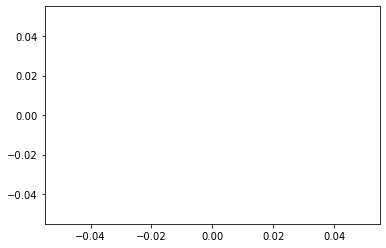

In [54]:
plt.plot(data1[:,0],data1[:,1],"o")

In [19]:
for ngrid in [32]:
    # alpha_halos_cdm=[]
    # alpha_halos_nu=[]
    # alpha_cdm_nu=[]
    # ##
    # bulk_vel_cdm=[]
    # bulk_vel_nu=[]
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    alpha_tot=0
    bulk_vel_tot=0
    for i in range(number_smaples):
        # sub_box_index = sub_box_lists[i]
        # cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # print(alpha_halos_cdm[0][2][0])
        alpha_tot = alpha_tot + alpha_halos_cdm[i][2][0];
        print(alpha_tot)
        bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu,vel_nu, sub_box_index)
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm,vel_cdm, sub_box_index)
        # print(bulk_vel_cdm_i[0][0])
        bulk_vel_tot = bulk_vel_tot+ bulk_vel_cdm_i[0][0]**2 + bulk_vel_cdm_i[0][1]**2 + bulk_vel_cdm_i[0][2]**2;
        
    



531.1197062817398
777.8782128488792
1713.5009289035186
1488.2648778297153
1763.8432940287883
2714.273143252761
1812.2541913793234
2394.1293014095227
2815.864202937502
2718.3025214921045


In [20]:
alpha_tot/bulk_vel_tot

0.0031623804776151057

In [18]:
for ngrid in [32]:
    alpha_halos_cdm=[]
    alpha_halos_nu=[]
    alpha_cdm_nu=[]
    ##
    bulk_vel_cdm=[]
    bulk_vel_nu=[]
    sub_box_lists = obj.Random_sub_box(ngrid,number_smaples);
    alpha_tot=0
    bulk_vel_tot=0
    for i in range(number_smaples):
        # sub_box_index = sub_box_lists[i]
        # cdm_vels = obj.vels_in_cell(ngrid, pos_cdm, vel_cdm, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        # halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)# Gives the velocities of objects in a cell defined by sub-box index!
        print(alpha_halos_cdm[0][2][0])
        # alpha_tot = alpha_tot + alpha_halos_cdm[i][2][0];
        print(alpha_tot)
        bulk_vel_nu_i = obj.velocity_bulk(ngrid, pos_nu,vel_nu, sub_box_index)
        bulk_vel_cdm_i = obj.velocity_bulk(ngrid, pos_cdm,vel_cdm, sub_box_index)
        # print(bulk_vel_cdm_i[0][0])
        bulk_vel_tot = bulk_vel_tot+ bulk_vel_cdm_i[0][0]**2 + bulk_vel_cdm_i[0][1]**2 + bulk_vel_cdm_i[0][2]**2;
        



[array([ 241.37897,  111.79085, -291.0371 ], dtype=float32),
 array([191.78474, 212.46721, 181.76381], dtype=float32)]

In [10]:
bulk_vel_cdm[i][2][0]

array([252.98038, -19.77907, 280.26508], dtype=float32)

In [7]:
from matplotlib.pyplot import figure

# figure(figsize=(8, 6), dpi=80)

for ngrid in [32]:
    for i in range(number_smaples):
        res = alpha_halos_cdm[i][2];
        # bulk_vel_cdm
        # bulk_vel_nu
        # plt.hist(bulk_vel_cdm[i][2][0],label="cell="+str(sub_box_lists[i]))
        # plt.legend()
        print("sub_box_lists:", sub_box_lists[i],"bulk_vel_cdm[i]:",bulk_vel_cdm[i][2][0], "bulk_vel_nu[i]:",bulk_vel_nu[i][2][0])
        

sub_box_lists: [ 5 25  8] bulk_vel_cdm[i]: [-44.17506   27.181595  25.64766 ] bulk_vel_nu[i]: [-25.607075 -18.662897 -19.519375]
sub_box_lists: [1 8 7] bulk_vel_cdm[i]: [ 292.66364  -374.60703   -17.504847] bulk_vel_nu[i]: [ 207.42365 -394.811    -59.27276]
sub_box_lists: [30 29  6] bulk_vel_cdm[i]: [-254.74544  131.52946 -171.85936] bulk_vel_nu[i]: [-234.40569  156.26952 -127.02946]
sub_box_lists: [28 27  2] bulk_vel_cdm[i]: [ 54.166187  85.01353  324.6364  ] bulk_vel_nu[i]: [ 84.85004 146.45479 241.71056]
sub_box_lists: [20  9 22] bulk_vel_cdm[i]: [-164.24161  -126.09723   100.488144] bulk_vel_nu[i]: [-149.56815  -75.58181   46.72005]
sub_box_lists: [10 26  5] bulk_vel_cdm[i]: [256.86432   48.970676 174.3442  ] bulk_vel_nu[i]: [255.8456   -16.143417 187.94385 ]
sub_box_lists: [17 24 25] bulk_vel_cdm[i]: [311.3315   221.92346  108.454865] bulk_vel_nu[i]: [238.89552  87.02274  39.15184]
sub_box_lists: [26 13 26] bulk_vel_cdm[i]: [ -54.2585  -110.90097  -83.14803] bulk_vel_nu[i]: [ -79.

In [8]:
for ngrid in [32]:
    for i in range(number_smaples):
        res = alpha_halos_cdm[i][2];
        # bulk_vel_cdm
        # bulk_vel_nu
        # plt.hist(bulk_vel_cdm[i][2][0],label="cell="+str(sub_box_lists[i]))
        # plt.legend()
        halos_vels = obj.vels_in_cell(ngrid, pos_halo_all, vel_halo_all, sub_box_index)
        print("sub_box_lists:", sub_box_lists[i],"bulk_vel_cdm[i]:",bulk_vel_cdm[i][2][0], "bulk_vel_nu[i]:",bulk_vel_nu[i][2][0],"1 halo:", halos_vels)
        
        
        

sub_box_lists: [ 5 25  8] bulk_vel_cdm[i]: [-44.17506   27.181595  25.64766 ] bulk_vel_nu[i]: [-25.607075 -18.662897 -19.519375] 1 halo: []
sub_box_lists: [1 8 7] bulk_vel_cdm[i]: [ 292.66364  -374.60703   -17.504847] bulk_vel_nu[i]: [ 207.42365 -394.811    -59.27276] 1 halo: []
sub_box_lists: [30 29  6] bulk_vel_cdm[i]: [-254.74544  131.52946 -171.85936] bulk_vel_nu[i]: [-234.40569  156.26952 -127.02946] 1 halo: []
sub_box_lists: [28 27  2] bulk_vel_cdm[i]: [ 54.166187  85.01353  324.6364  ] bulk_vel_nu[i]: [ 84.85004 146.45479 241.71056] 1 halo: []
sub_box_lists: [20  9 22] bulk_vel_cdm[i]: [-164.24161  -126.09723   100.488144] bulk_vel_nu[i]: [-149.56815  -75.58181   46.72005] 1 halo: []
sub_box_lists: [10 26  5] bulk_vel_cdm[i]: [256.86432   48.970676 174.3442  ] bulk_vel_nu[i]: [255.8456   -16.143417 187.94385 ] 1 halo: []
sub_box_lists: [17 24 25] bulk_vel_cdm[i]: [311.3315   221.92346  108.454865] bulk_vel_nu[i]: [238.89552  87.02274  39.15184] 1 halo: []
sub_box_lists: [26 13 2

In [17]:
bulk_vel_cdm[i][2][0]

array([ 241.37897,  111.79085, -291.0371 ], dtype=float32)

In [16]:
a = [-94.57076, -78.30432, 221.93622];
b = [-30.901358, -69.10592,  289.38004 ];
np.dot(a,b)/np.dot(b,b)

0.8109588790614242

## PLotting alphas

In [15]:
from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)

for ngrid in [32]:
    for i in range(10):
        res = alpha_halos_nu[i][2];
        print(res)
        # plt.hist(res)

[-0.14673103 -0.14673103 -0.14673103 ... -0.14673103 -0.14673103
 -0.14673103]
[0.00165242 0.00165242 0.00165242 ... 0.00165242 0.00165242 0.00165242]
[-0.01051393 -0.01051393 -0.01051393 ... -0.01051393 -0.01051393
 -0.01051393]
[0.00859481 0.00859481 0.00859481 ... 0.00859481 0.00859481 0.00859481]
[-0.0409267 -0.0409267 -0.0409267 ... -0.0409267 -0.0409267 -0.0409267]
[0.01462629 0.01462629 0.01462629 ... 0.01462629 0.01462629 0.01462629]
[0.02695287 0.02695287 0.02695287 ... 0.02695287 0.02695287 0.02695287]
[-0.02979151 -0.02979151 -0.02979151 ... -0.02979151 -0.02979151
 -0.02979151]
[-0.01579629 -0.01579629 -0.01579629 ... -0.01579629 -0.01579629
 -0.01579629]
[0.01421813 0.01421813 0.01421813 ... 0.01421813 0.01421813 0.01421813]


<Figure size 640x480 with 0 Axes>

# Functions

In [23]:

# def nested_dict(n, type):
#     if n == 1:
#         return defaultdict(type)
#     else:
#         return defaultdict(lambda: nested_dict(n-1, type))
# data = nested_dict(9, list)

# def norm(x):
#     """norm of a vector"""
#     return np.sqrt(sum(x_i*x_i for x_i in x));

# def dot(x, y):
#     """Dot product of two vectors"""
#     return sum(x_i*y_i for x_i, y_i in zip(x, y));

# def velocity_bulk(ngrid, boxsize, pos,vel, sub_box_index):
#     """computing the bulk velocity in a sub-box using the velocities of objects"""
#     condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
#     condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
#     condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
#     condition_tot = (condition_x) & (condition_y) & (condition_z)
#     vel_grids= np.array([np.average(vel[condition_tot,0]),np.average(vel[condition_tot,1]),np.average(vel[condition_tot,2])])
#     return vel_grids; #/norm(vel_grids);

# def alpha_list(vel, velocity_bulk):
#     """computing alpha for halos/particle using the bulk velocity. The output is an array containing velocities."""
#     alpha = np.zeros((np.shape(vel)[0]));
#     for i in range(np.shape(vel)[0]):
#         alpha[i] = dot(vel[i,:], velocity_bulk)/norm(velocity_bulk)
#     return alpha;

# def halo_selection(data_address, string, mass_limit): # Todo: Produce both halo catalogues together to save memory!
#     """computing the halo population obtained by a mass limit and whether we want larger or smaller halos. The output is 
#     [x,y,z,v_x,v_y,v_z,Rvir,M200b]"""
#     data = np.loadtxt(data_address);
#     if (string == "+"):
#         condition = data[:,20]> mass_limit;
#         halo_pop = np.zeros((np.shape(data[condition])[0],8))
#         for i in range(6):
#             halo_pop[:,i] = data[condition][:,8+i]
#         halo_pop[:,6] = data[condition][:,5] # R_vir
#         halo_pop[:,7] = data[condition][:,20] # Mass
#     if (string == "-"):
#         condition = data[:,20]<= mass_limit;
#         halo_pop = np.zeros((np.shape(data[condition])[0],8))
#         for i in range(6):
#             halo_pop[:,i] = data[condition][:,8+i]
#         halo_pop[:,6] = data[condition][:,5] # R_vir
#         halo_pop[:,7] = data[condition][:,20] # Mass
#     return halo_pop;

# def halos_in_cell_vel(ngrid, boxsize, pos,vel, sub_box_index): 
#     """outputting the velocity of halos in the give sub-box """
#     condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== sub_box_index[0])
#     condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== sub_box_index[1])
#     condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== sub_box_index[2])
#     condition_tot = (condition_x) & (condition_y) & (condition_z)
#     vel_halos =vel[condition_tot];
#     # pos_halos =pos[condition_tot]
#     return vel_halos # For test you can output pos[vel_halos, pos_halos];

# def halo_header(address, column=-1):
#     """Takes the address of the halo and reads the header by default. If the column is specified then just prints the corresponding column!"""
#     f = open(address)
#     header = f.readline()
#     header_list = header.split(' ') #list of columns
#     # print(header_list)
#     if column==-1:
#         for i in range(np.shape(header_list)[0]):
#             print(str(i)+":"+header_list[i])
#     if column!=-1:
#         print(str(column)+":"+header_list[column])

        
# def halo_load(address): # Todo: keep only certain columns! Also rewrite halo_population
#     """Takes the address of the halo and load the file!"""
#     data= np.loadtxt(address)
#     return data;

# def cdm_gadget_load(snapshot, ptype=[1]):
#     """Takes the address of the CDM gadget 2 snapshot and returns the pos and velocity of particles!"""
#     pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
#     vel = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
#     # ids = readgadget.read_block(snapshot, "ID  ", ptype)-1   #IDs starting from 0
#     return np.array([pos,vel])



# Loading data

In [51]:
for ngrid in [3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="y"
    for num in [3]: # the snapshot number start from high redshift
        data_ls1 = []

        for sim in ['Mn_0d6']:
            
            ######################
            snapshot = './../Simulations/'+sim+'/output/snap00'+str(num)+'_cdm'
            halo = np.loadtxt('./../Simulations/'+sim+'/output/halos/out_'+str(num)+'.list')
            ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
            pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
            vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
            ######################
            # Selecting two halo populations:
            halo_pop1=halo_population(halo, "+", mass_limit)
            halo_pop2=halo_population(halo, "-", mass_limit)
            # pos_h1 = halo_pop1[:,0:3]
            # vel_h1 = halo_pop1[:,3:6]
            # Loop over all subboxes
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        # v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index) # Bulk velocity
                        v_c_s =velocity_bulk(ngrid, boxsize, halo_pop1[:,0:3],  halo_pop1[:,3:6], sub_box_index) # Bulk velocity
                        v_c_l =velocity_bulk(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # Bulk velocity
                        v_c =  (v_c_s + v_c_l)/2.;
                        v_diff = (v_c_s - v_c_l);
                        data_ls1.append(dot(v_diff,v_c)/dot(v_c,v_c));
                        # data['alpha_list']['sim='+sim]=
                        # v_h_p1 = halos_in_cell_vel(ngrid, boxsize, halo_pop1[:,0:3], halo_pop1[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # v_h_p2 = halos_in_cell_vel(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # if (np.shape(v_h_p1)[0]==0) & (np.shape(v_h_p2)[0]==0):                        
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     print("cell:"+str(sub_box_index)+", no halo found!")
                        # else:
                        #     if verbose=="y":
                        #         print("cell:"+str(sub_box_index)+", found "+'\033[91m'+str(np.shape(v_h_p1)[0])+ '\033[0m'+" halo log(M)>"+str(np.round(np.log10(mass_limit),2))+" and "+'\033[34m'+str(np.shape(v_h_p2)[0])+'\033[0m' +" halo log(M)<"+str(np.round(np.log10(mass_limit),2))+", simulation="+sim)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p1, v_c)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p2, v_c)
                        #     ### Avg in a cell!
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p1, v_c))
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p2, v_c))
                            
            print("******************************sim:"+sim+", dx= "+str(boxsize/ngrid)+"[Mpc/h] Done!**************************************")

            

******************************sim:Mn_0d6, dx= 341.3333333333333[Mpc/h] Done!**************************************


In [52]:
for ngrid in [3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="y"
    for num in [3]: # the snapshot number start from high redshift
        data_ls2 = []
        for sim in ['lcdm']:
            ######################
            snapshot = './../Simulations/'+sim+'/output/snap00'+str(num)+'_cdm'
            halo = np.loadtxt('./../Simulations/'+sim+'/output/halos/out_'+str(num)+'.list')
            ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
            pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
            vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
            ######################
            # Selecting two halo populations:
            halo_pop1=halo_population(halo, "+", mass_limit)
            halo_pop2=halo_population(halo, "-", mass_limit)
            # pos_h1 = halo_pop1[:,0:3]
            # vel_h1 = halo_pop1[:,3:6]
            # Loop over all subboxes
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        # v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index) # Bulk velocity
                        v_c_s =velocity_bulk(ngrid, boxsize, halo_pop1[:,0:3],  halo_pop1[:,3:6], sub_box_index) # Bulk velocity
                        v_c_l =velocity_bulk(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # Bulk velocity
                        v_c =  (v_c_s + v_c_l)/2.;
                        v_diff = (v_c_s - v_c_l);
                        data_ls2.append(dot(v_diff,v_c)/dot(v_c,v_c));
                        # data['alpha_list']['sim='+sim]=
                        # v_h_p1 = halos_in_cell_vel(ngrid, boxsize, halo_pop1[:,0:3], halo_pop1[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # v_h_p2 = halos_in_cell_vel(ngrid, boxsize, halo_pop2[:,0:3], halo_pop2[:,3:6], sub_box_index) # velocities of halos (population 1)
                        # if (np.shape(v_h_p1)[0]==0) & (np.shape(v_h_p2)[0]==0):                        
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     data['alpha_list']['mass_limit='+str(mass_limit)]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = 0
                        #     print("cell:"+str(sub_box_index)+", no halo found!")
                        # else:
                        #     if verbose=="y":
                        #         print("cell:"+str(sub_box_index)+", found "+'\033[91m'+str(np.shape(v_h_p1)[0])+ '\033[0m'+" halo log(M)>"+str(np.round(np.log10(mass_limit),2))+" and "+'\033[34m'+str(np.shape(v_h_p2)[0])+'\033[0m' +" halo log(M)<"+str(np.round(np.log10(mass_limit),2))+", simulation="+sim)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p1, v_c)
                        #     # data['alpha_list']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = alpha_list(v_h_p2, v_c)
                        #     ### Avg in a cell!
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p1, v_c))
                        #     data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]] = np.average(alpha_list(v_h_p2, v_c))
                            
            print("******************************sim:"+sim+", dx= "+str(boxsize/ngrid)+"[Mpc/h] Done!**************************************")

            

******************************sim:lcdm, dx= 341.3333333333333[Mpc/h] Done!**************************************


In [18]:
import random
ngrid= 100;
a = np.transpose([random.sample(range(1, 100), 3),random.sample(range(1, 100), 3),random.sample(range(1, 100), 3)])




In [19]:
np.shape(a)

(3, 3)

In [20]:
a

array([[43, 45, 53],
       [35, 48, 54],
       [68, 30, 32]])

In [14]:
a[1]

[11, 15, 49]

<ipython-input-56-b7bca3e510e7>:2: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


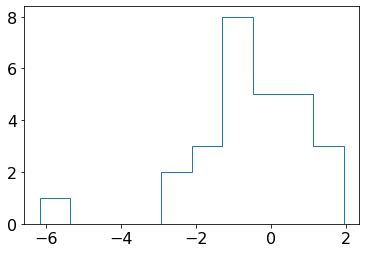

In [56]:

counts, bins = np.histogram(np.array(data_ls2)-np.array(data_ls1), bins=10, range=None, normed=None, weights=None, density=None)
plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
# plt.legend()
 

<ipython-input-32-129abb71fb07>:2: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


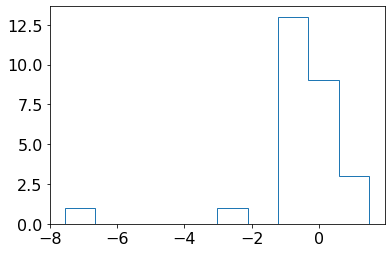

In [32]:

counts, bins = np.histogram(data_ls, bins=10, range=None, normed=None, weights=None, density=None)
plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
# plt.legend()
 

# $\alpha$ histogram for a given $N_{grid}$

<ipython-input-22-6d078357fcce>:20: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


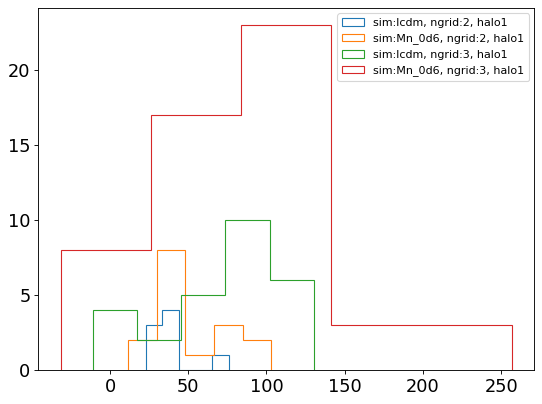

In [22]:
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)

for ngrid in [2,3]:
    boxsize=1024.;
    mass_limit = 1.e14;
    verbose="n"
    alpha_all_h1=[]
    alpha_all_h2=[]
    for num in [3]: # the snapshot number start from high redshift
        for sim in ['lcdm', 'Mn_0d6']:
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
                        alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

            counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
            plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
            plt.legend()
            ######
            # counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
            # plt.stairs(counts, bins, alpha=0.1, hatch='.',fill=True, label="sim:"+sim+", ngrid:"+str(ngrid)+", halo2")
            plt.legend()
# plt.

## $\alpha$ for different $N_{grids}$

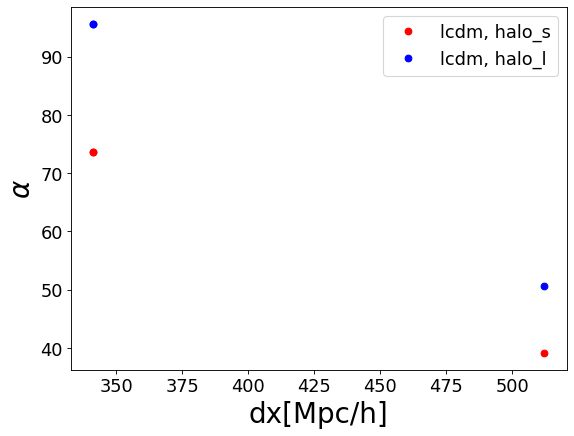

In [24]:
from matplotlib.pyplot import figure
figure(figsize=(8, 6), dpi=80)
# for sim in ['lcdm', 'Mn_0d6']:
for sim in ['lcdm']:

    for ngrid in [2,3]:
        boxsize=1024.;
        mass_limit = 1.e14;
        verbose="n"
        alpha_all_h1=[]
        alpha_all_h2=[]
        for num in [3]: # the snapshot number start from high redshift
            for i in range(ngrid):
                for j in range(ngrid):
                    for k in range(ngrid):
                        sub_box_index=[i,j,k];
                        alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
                        alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

                        
        x1 = [boxsize/ngrid] 
        y1 = [np.average(alpha_all_h1)]
        # print(arr)
        plt.plot(x1,y1,"ro")  
        
        x = [boxsize/ngrid] 
        y = [np.average(alpha_all_h2)]
        plt.plot(x,y,"bo")
            # plt.plot(boxsize/ngrid, np.average(alpha_all_h2), label="sim:"+sim+", halo12)        
    plt.plot(x1,y1,"ro", label=sim+", halo_s")
    plt.plot(x,y,"bo", label=sim+", halo_l")
    
plt.rcParams['xtick.labelsize']=16
plt.rcParams['ytick.labelsize']=16
plt.xlabel("dx[Mpc/h]",fontsize=25)
plt.ylabel(r"$\alpha$",fontsize=25)
plt.legend(fontsize=16)
# plt.

In [14]:
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# import matplotlib.cm as cm
# cmap = cm.get_cmap("jet",lut=6)

# v_c =velocity_bulk(ngrid, boxsize, pos_cdm, vel_cdm, sub_box_index)
# x = np.arange(0, grid, 1)*boxsize/grid
# y = np.arange(0, grid, 1)*boxsize/grid
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+")
# plt.colorbar(plot)

NameError: name 'grid' is not defined

<Figure size 960x800 with 0 Axes>

## Plot

In [306]:
# # 
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# import matplotlib.cm as cm



# # cmap = cm.get_cmap("jet",lut=6)
# cmap = cm.get_cmap("jet")
# # cmap.set_under("w")

# ####
# x = np.arange(0, grid, 1)*1024./grid
# y = np.arange(0, grid, 1)*1024./grid
# z_s=10
# vmax = 0.05 ;vmin=-0.06
# plot = plt.pcolormesh(x, y, delta_n[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_n[:,:,z_s], cmap='gray')
# # plt.clabel(cset, inline=False)
# plt.title("phase-")
# plt.colorbar(plot)

# ##########################
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+")
# plt.colorbar(plot)

# ##########################
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_g[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("Gaussian")
# plt.colorbar(plot)

In [133]:
# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)
# plot = plt.pcolormesh(x, y, delta_p[:,:,z_s]+delta_n[:,:,z_s], cmap=cmap, shading='flat',vmin =vmin, vmax = vmax)
# # cset = plt.contour(x, y, delta_p[:,:,z_s])
# # plt.clabel(cset, inline=False)
# plt.title("phase+ + phase-")
# plt.colorbar(plot)

## Power spectra

In [305]:
# import Pk_library as PKL
# threads=12

# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)

# pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_p_pk000_delta.dat")
# pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_n_pk000_delta.dat")
# pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed1/lcdm_g_pk000_delta.dat")
# pk_class= np.loadtxt("./test_runs_Ismael_project/output_class/lcdm_n__classz2_pk.dat")

# kgev=pk_gev_p[:,0]
# # compute power spectrum
# Pk_p = PKL.Pk(delta_p, BoxSize, axis, MAS, threads, verbose)
# Pk_n = PKL.Pk(delta_n, BoxSize, axis, MAS, threads, verbose)
# Pk_g = PKL.Pk(delta_g, BoxSize, axis, MAS, threads, verbose)

# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# # 3D P(k)
# k       = Pk_p.k3D
# Pk0_p     = Pk_p.Pk[:,0] #monopole
# Pk0_n     = Pk_n.Pk[:,0] #monopole
# Pk0_g     = Pk_g.Pk[:,0] #monopole

# plt.loglog(k,Pk0_p,"o",label="Pylians, phase+")
# plt.loglog(k,Pk0_n,"o",label="Pylians, phase-")
# plt.loglog(k,Pk0_g,"o",label="Pylians, Gaussian")
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")

# plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="phase+, gev")
# plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="phase-, gev")
# plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="Gaussian, gev")


# dk = kgev - roll(kgev,-1)
# #### bins class
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")


# # pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_p_pk000_delta.dat")
# # pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_n_pk000_delta.dat")
# # pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed2/lcdm_g_pk000_delta.dat")


# # plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, Gaussian, gev")

# # plt.loglog(k,Pk0_p,"*",label="seed2, phase+")
# # plt.loglog(k,Pk0_n,"*",label="seed2, phase-")
# # plt.loglog(k,Pk0_g,"*",label="seed2, Gaussian")


# plt.ylim(0.01,10)
# plt.xlim(1.e-3,1)

# plt.legend(fontsize=16)
# plt.xlabel("$k[h/Mpc]$",fontsize=24)
# plt.ylabel("$P[Mpc^3/h^3]$",fontsize=24)


In [304]:
# import Pk_library as PKL
# threads=12

# from matplotlib.pyplot import figure
# figure(figsize=(12, 10), dpi=80)

# pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_p_pk000_delta.dat")
# pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed1//lcdm_n_pk000_delta.dat")
# pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed1/lcdm_g_pk000_delta.dat")
# pk_class= np.loadtxt("./test_runs_Ismael_project/output_class/lcdm_n__classz2_pk.dat")

# kgev=pk_gev_p[:,0]
# # # compute power spectrum
# # Pk_p = PKL.Pk(delta_p, BoxSize, axis, MAS, threads, verbose)
# Pk_n = PKL.Pk(delta_n, BoxSize, axis, MAS, threads, verbose)
# # Pk_g = PKL.Pk(delta_g, BoxSize, axis, MAS, threads, verbose)

# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# # 3D P(k)
# # k       = Pk_p.k3D
# # Pk0_p     = Pk_p.Pk[:,0] #monopole
# # Pk0_n     = Pk_n.Pk[:,0] #monopole
# # Pk0_g     = Pk_g.Pk[:,0] #monopole

# # plt.loglog(k,Pk0_p,"o",label="Pylians, phase+")
# # plt.loglog(k,Pk0_n,"o",label="Pylians, phase-")
# # plt.loglog(k,Pk0_g,"o",label="Pylians, Gaussian")
# # plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")

# plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="Gaussian, gev")


# # dk = kgev - roll(kgev,-1)
# #### bins class
# plt.loglog(pk_class[:,0],pk_class[:,1],"-.",label="CLASS")


# # pk_gev_p= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_p_pk000_delta.dat")
# # pk_gev_n= np.loadtxt("./test_runs_Ismael_project/output_seed2//lcdm_n_pk000_delta.dat")
# # pk_gev_g= np.loadtxt("./test_runs_Ismael_project/output_seed2/lcdm_g_pk000_delta.dat")


# # plt.loglog(kgev,pk_gev_p[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase+, gev")
# # plt.loglog(kgev,pk_gev_n[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, phase-, gev")
# # plt.loglog(kgev,pk_gev_g[:,1]*2.*np.pi**2/kgev**3,"*",label="seed2, Gaussian, gev")

# # plt.loglog(k,Pk0_p,"*",label="seed2, phase+")
# # plt.loglog(k,Pk0_n,"*",label="seed2, phase-")
# # plt.loglog(k,Pk0_g,"*",label="seed2, Gaussian")


# plt.ylim(0.01,10)
# plt.xlim(1.e-3,1)

# plt.legend(fontsize=16)
# plt.xlabel("$k[h/Mpc]$",fontsize=24)
# plt.ylabel("$P[Mpc^3/h^3]$",fontsize=24)


Text(0, 0.5, '$P[Mpc^3/h^3]$')

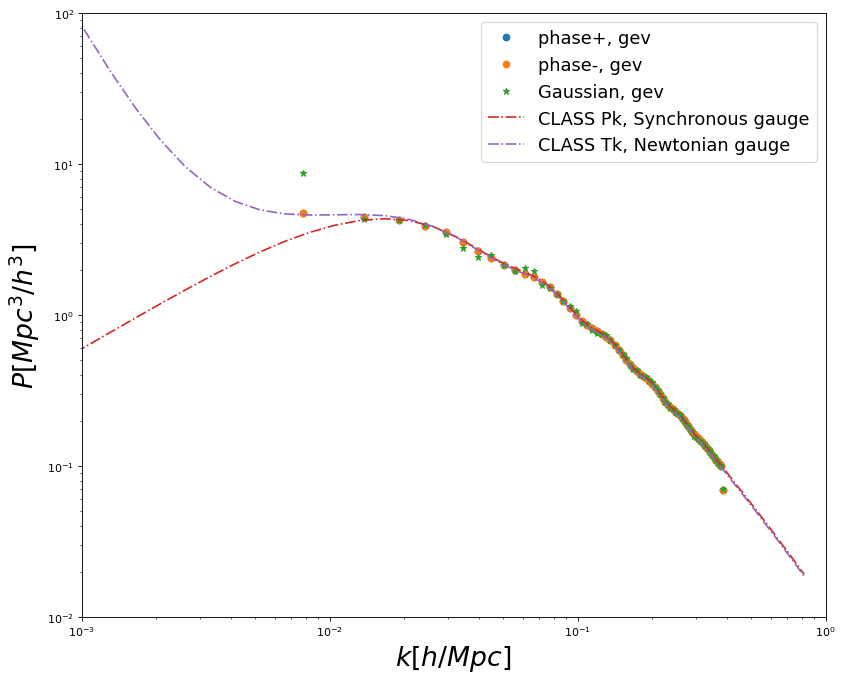

In [212]:
# def nested_dict(n, type):
#     if n == 1:
#         return defaultdict(type)
#     else:
#         return defaultdict(lambda: nested_dict(n-1, type))
    
# data = nested_dict(4, list)

    # read header
    # header   = readgadget.header(snapshot)
    # BoxSize  = header.boxsize/1e3  #Mpc/h
    # Nall     = header.nall         #Total number of particles
    # Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
    # Omega_m  = header.omega_m      #value of Omega_m
    # Omega_l  = header.omega_l      #value of Omega_l
    # h        = header.hubble       #value of h
    # redshift = header.redshift     #redshift of the snapshot
    # Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
    # read positions, velocities and IDs of the particles

In [2]:
import numpy as np
class massive_neutrinos:
    """
    Class for massive neutrino project
    """
    def __init__(self):
        # self.comm = MPI.COMM_WORLD
        return
    
    def nested_dict(self, n, type):
        """ Definition of nested dictionary """
        if n == 1:
            return defaultdict(type)
        else:
            return defaultdict(lambda: nested_dict(n-1, type))
        
    def norm(self, x):
        """ norm of a vector """
        return np.sqrt(sum(x_i*x_i for x_i in x));

    def dot(self, x, y):
        """Dot product of two vectors"""
        return sum(x_i*y_i for x_i, y_i in zip(x, y));
    
    def dist(self, x, y):
        """Distance of two points"""
        return self.norm(np.subtract(x,y)) ;
    
    def halo_selection(self, data, string, mass_limit): 
        """ outputting a halo population obtained by a mass limit and whether we want larger or smaller halos.
            input: data (halo catalogue from Rockstar), a string being + or -, and mass limit in solar mass.
            output: A new catalogue with [x,y,z,v_x,v_y,v_z,Rvir,M200b] of halo population
        """
        if (string == "+"):
            condition = data[:,20]> mass_limit;
            halo_pop = np.zeros((np.shape(data[condition])[0],8))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            halo_pop[:,6] = data[condition][:,5] # R_vir
            halo_pop[:,7] = data[condition][:,20] # Mass
        if (string == "-"):
            condition = data[:,20]<= mass_limit;
            halo_pop = np.zeros((np.shape(data[condition])[0],8))
            for i in range(6):
                halo_pop[:,i] = data[condition][:,8+i]
            halo_pop[:,6] = data[condition][:,5] # R_vir
            halo_pop[:,7] = data[condition][:,20] # Mass
        return halo_pop;


In [7]:
obj = massive_neutrinos();
x = [0,0,0]
y = [3,3,3]
obj.dist(x,y)

5.196152422706632

In [16]:
x = [0,0,0]
y = [1,1,1]

In [13]:
x[:]-y[:]

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [17]:
np.subtract(x,y)

array([-1, -1, -1])

In [4]:
import random

import numpy as np

In [2]:
a = [1,2,3,4,5]
np.average(a)

3.0

In [3]:
np.std(a)

1.4142135623730951

In [2]:
 def Random_sub_box(ngrid, number):
        """Takes the number of grids and return N randomly chosen sub-box indices! 
        """
        res = np.transpose([random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number),random.sample(range(0, ngrid), number)])
        return res

In [6]:
a = Random_sub_box(4, 3)

In [11]:
a

array([[1, 3, 0],
       [2, 1, 3],
       [0, 2, 1]])

In [10]:
for i,j,k in a:
    print(i,j,k)

1 3 0
2 1 3
0 2 1
